### Topics Covered
- Introduction to Sorting
- Insertion Sort
- Selection Sort
- Bubble Sort
- Shell Sort
- Heap Sort
- Merge Sort
- Quick Sort
- Radix Sort
- Use Cases

### Introduction

In this section we'll talk about a fundamental concept in computer science. And that is sorting. Sorting is the process of organizing data in a meaningful order. Keeping a collection sorted brings an undeniable advantage regardless of its size



Searching, accessing and processing data is considerably easier on a collection that's sorted. And in today's day and age, we have more data than ever. Big companies use all kinds of sorting methods to organize the products and services they sell. YouTube, for instance, allows you to sort videos of a channel based on criteria like popularity or date added. Online stores like Amazon or eBay give you the ability to sort the products in a variety of ways. Netflix also sorts their movies and shows, and the list can go on. In this world of data driven technologies, efficient sorting of large datasets can save precious time, which ultimately translates into saving lots of money.

One thing worth mentioning is that typically we sort items by doing comparisons. There are some algorithms that sort without comparing items, and we'll see an example of that in a future video. But the general approach is to compare the values to determine if they're out of order, and then move them in a sorted position. And this is also true for text and time data under the hood.

Our computers store them as bytes, so when we compare timestamps, for example, we're actually comparing their numeric representation. Since this is such an important topic in the world of computers, there's been a vast amount of time spent researching and developing the most efficient sorting algorithms .But **what does efficiency mean when we talk about sorting?** How do we measure that?

One common way to benchmark a sorting method is to
  1. count the number of comparisons and 
  2. the number of data movements it does. 

We can have an algorithm that does a lot of comparisons and then a limited amount of data swaps, and we can have one that does less comparisons but more data movements. One is not necessarily better than the other .It depends on the type of data we're sorting. For very large objects that occupy a lot of memory, having less movements could be better for performance, even if that comes with more comparisons. Strings or other sequences of data might not be too expensive to move around, but might have increased costs of comparisons as opposed to simpler data like integers, for instance .So it's all situational

Now, does this mean we'll have to count every single operation our algorithm does? Well not really. Since doing such a thing is a lot of times impractical and usually reserved for theoretical study, what we can do instead is approximate the performance of our algorithms with our trusty old method, the big O notation. By analyzing our code structure, we can give a pretty accurate estimation of what the performance of our sorting algorithms will be

### Insertion Sort

The first sorting algorithm we'll look at is called insertion sort. When doing insertion sort, we need to choose one end of the array to start at. The idea behind insertion sort is to start at the beginning of the array and compare the number you're currently at with all the ones that came before it. And if it's out of order, place it in the correct spot


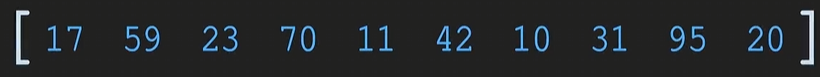

For our sample list we have here, if we were to start at `17`, we wouldn't have anything to compare it to because there are no other elements before it. It's the first one. So, our algorithm will actually have to start with the **second element** (`59`), and then compare it to all the others that came before it. In this first iteration, it will only compare `59` to `17`. And since `59` is larger, we don't take any action. They're already in the correct order. 

We then move on to the next element and start comparing it to the previous one `23` is smaller than `59`, so We basically swap the two values in place and then we don't move to `70` just yet, but rather compare `23` with the one before it, in this case `17`, We can see that they're already in the correct order, so we don't do anything. But our algorithm couldn't have known that, so it had to do the comparison. After we find the correct place for our current number, we continue forwards in the list to number `70`, `70` is greater than `59` so we dont do any changes and move on to `11`. After comparing `11` with `70`, we realized they're out of order. So we swap them and then keep comparing `11` with all the numbers before it and swapping if necessary, and we keep going until we reach the first element(`11`)

In this case, we actually had to go all the way to the first position in the array to find its correct place. And this action of going backwards with the comparisons will have to do for all the numbers that are left in the array.

Notice two things. Firstly, all the numbers we leave behind are sorted and after we swap the element we're currently at and compare it to the ones before it, we stop when we find the first one that's smaller. This means that all the new elements we're bringing into this sorted part of the array will not change this sorted state we have now.

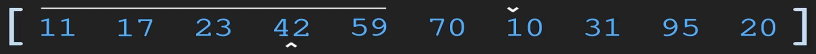

And secondly, the length of this array we leave behind is growing with each iteration. So the distance we have to travel when we compare and swap values will grow as we near the end of our array, eventually becoming its full length in the last run

**so how would we write this logic in code?**

we would need two loops. The first one will go from the beginning of the array (`top pointer`), from the second element to be more precise until the end. And the second loop (`bottom pointer`) will go from the element we're currently at backwards towards the start of the array, While comparing and swapping elements if necessary. 

So once again, we have one loop (`top pointer`) that starts at the second element and goes until the end of the array(`goes forwards`). And inside this loop we take the element we're currently at and have another loop (`bottom pointer`) that compares it to the one before it(`goes backwards`). If it's smaller, we swap and then we compare it to the next one before it, and we repeat this process until we either find one element that's smaller or we reach position zero of the array

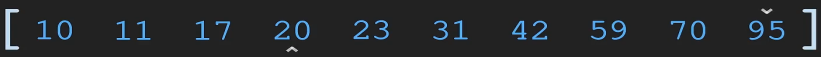

**Note : This algorithm is that it does not create a new list, we don't read the numbers from the initial list and put them in order in a new one. We just swap them in place**

It’s called **insertion sort** because the algorithm’s defining action is inserting each element into its correct position within the already-sorted portion of the array.

Here’s the subtlety:
- You’re right that we’re not “inserting” in the sense of adding new elements to the array. The array size doesn’t change.
- But conceptually, at each step we take the current element (the “key”) and **insert it into the right place among the elements to its left, shifting others as needed.**

Example
Suppose the array is [5, 3, 4]:
- Start with index 1 (3). The sorted part is [5].
  - Insert 3 into [5] → [3, 5].
- Next index 2 (4). The sorted part is [3, 5].
  - Insert 4 into [3, 5] → [3, 4, 5].

Notice how each step is about insertion into a sorted subarray, not just swapping. That’s why the name sticks.

Other sorts are named after their defining action too:
- `Selection sort`: repeatedly selects the smallest element.
- `Bubble sort`: repeatedly bubbles the largest element to the end.
- `Merge sort`: repeatedly merges sorted halves.


**Analogy**

Insertion Sort = Sorting Cards in Your Hand
Imagine you’re playing cards.
- You hold a few cards already sorted.
- You pick up a new card and insert it into the right spot among the ones you’re holding.
- Each time you add a card, your hand stays sorted.
That’s insertion sort: build the sorted list one element at a time by inserting each new item where it belongs.

- Insertion Sort → insert into the right spot.

In [5]:
def insertion_sort(array):
# i becomes the top pointer which keeps going forward, while j is the bottom pointer which travels back to ensure everything behind is sorted but joins
# back with j whenever the sorting is completed behind or when the while loop is exited
# for loop is to start from index 0 and end at 9 + assign top & bottom pointers the same value
    for i in range(1, len(array)):#since we start comparing from 2nd element (index=1) we start the range from 1 and end 1 less than array total elements
        j = i # both pointers will be at the same index when starting or when the previous elements are all sorted in order by below while loop 
# while loop is to ensure prev value is compared with current value + the bottom pointer has reached first value after backward comparison
        while array[j-1] > array[j] and j > 0 : #continues only if the prev element is higher than current,else go back to for loop & start with next num
# since j is the bottom pointer, we also have to make sure its greater than 0(first element)
            array[j-1],array[j] = array[j], array[j-1] # swap the values using indexes
            j-= 1 # once the swap happens we continue the loop by shifting one step back and keep doing it till we have reached index 0 at which 
    return array  # we exit the while loop

In [3]:
my_array = [17,59,23,70,11,42,10,31,95,20]
my_array

[17, 59, 23, 70, 11, 42, 10, 31, 95, 20]

In [7]:
sorted_array = insertion_sort(my_array)

In [9]:
print(sorted_array)

[10, 11, 17, 20, 23, 31, 42, 59, 70, 95]


#### Time And Space Complexity

When talking about sorting algorithms, we usually think about the runtime in terms of best, average, and worst performances.
we don't create a new array. We don't add new things to memory. We only create two variables, which we keep updating in a loop, and we swap some elements in their correct location. So the space complexity of insertion sort is O(1).

Let's now see what the deal is with the different runtime performances. Well, it all depends on the state of the array. And what I mean by that is maybe the array we're trying to sort is already sorted, or maybe it's reversed or just completely randomized. Let's try to understand how these cases could impact the performance. Our computers can't know in advance if an array is sorted or reversed. It will have to apply the same procedure for all of them.

So for a sorted array, it will start with the main loop from the second element until the end like normal. But when it starts comparing elements, it will never have to enter the second loop, because at any point in the iteration, the current number we're at is greater than the one before it, so we never have to do any swaps. Therefore, for a sorted array, what we end up doing is only the initial for loop over the entire array, and one run over all the elements of an array is exactly an O(n) complexity. 

**Scenario 1 : Sorted Array**

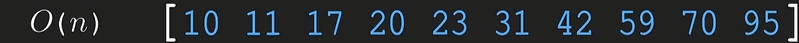

On a sorted array, but in reversed order. Things are the complete opposite. The main loop will run just as before, but unlike the previous example, this time the internal loop will run at full capacity every time. It will have to travel and do swaps all the way back to the first index. And even if in the first part of the array, it doesn't have to do too many iterations. As it goes further, the total number of operations it does grows. So in this situation, we have one loop that runs inside another one for the entire length of the array. And this is an O(n) squared complexity.

**Scenario 2 : Sorted Array in Reversed Order**

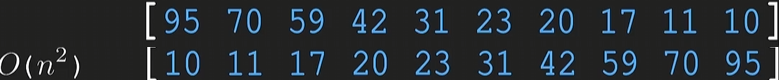

But what if it's neither sorted nor reversed, but randomized? Well, this would come somewhere in between the two cases. But from a theoretical standpoint, this is still O(n) squared like the reversed case. In a practical scenario, it's true that it would do less comparisons and swaps than a reversed array. But since complexity analysis considering the growth of functions, in this case it's closer to the reversed case. So this is also O(n) squared.

**Scenario 3 : Randomized Array**

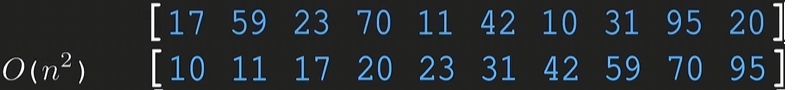

So these three examples would represent the best, worst and average performances of this sorting method. But I want us to have a look at one more scenario. There might be a case in the real world where we would have a list that's almost sorted. An example of such a list would be one that has only a few elements that are not sorted, and are also not too far away from their correct location. In such a situation, the internal wire loop will have to run only a couple of times and hopefully do very few swaps, so its complexity isn't really n times n. For it to be n squared, because the inner loop will not run n times, it will do a negligible number of operations. So in practice the time complexity would actually tend towards O(n).

**Scenario 4 : Almost Sorted Array**

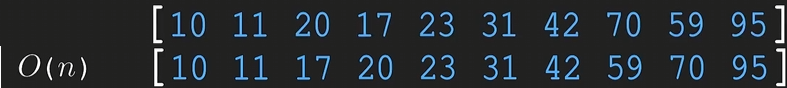

So this brings us to the discussion as to when insertion sort would be a preferred sorting algorithm. O(n) squared is not the best possible complexity for a sorting algorithm, but there are some cases where insertion sort might be useful. It's usually very fast for small sized arrays. It's even faster on small arrays than some other algorithms because it doesn't have too much overhead. It just compares two values and swaps indices. It's quite a barebone algorithm, and that makes it a preferred choice for small arrays. Another case would be the one we just saw with arrays that are almost sorted because it only moves values around only when it's necessary, and since in this case it's not that often, it's quite a good solution for such a scenario, even for medium to large size arrays.

##### Time Complexity of Insertion Sort

- Best Case: O(n)  
- Average Case: O(n²)
- Worst Case: O(n²)

##### Space : O(1)

#### Practical Use Case of Insertion Sort
- **Where used**: Small datasets, nearly sorted arrays.
- **How used**: Efficient for adaptive sorting (e.g., inserting new records into a sorted list).
- **Example**: Maintaining a sorted leaderboard when new scores arrive.

### Selection Sort

The second sorting algorithm we'll be covering is called selection sort. Unlike insertion sort, which compares and swaps elements with each iteration. Selection sort will first scan the entire array from start to finish, and then put the element in its correct location with a single swap, and the logic will look like this. We need to start scanning our array from one of its ends. And again, we could use either of them. But I'll start from the left and mark the current element we visited in this current iteration as the smallest.

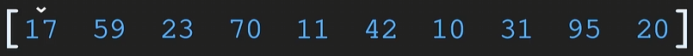

In this case, we start at `17` and we mark it as the smallest because it's the only one we visited so far. We then continue to the next element and we compare it to the current known smallest one. `59` is greater than `17`, so we move on, `23` is also greater than `17` and so is `70`. But when we reach `11` it is now the smallest value we encountered so far. So, we mark it as the smallest. We then continue to `42` and we compare it to the current smallest one, which is not `17` anymore, but `11`, `42` is greater than `11`, so we continue to the next one. We again find a number smaller than the one we had before, so we now mark `10` as the smallest. The loop will then continue until the end. And when it finishes, we swap the current smallest value with the one we started at in this iteration. In our case, swap `10` with `17`. And now we know that `10`  is in its correct spot at position zero in the list, since it was the smallest one when we did this first scan of the list. We then moved to the second number(`59`)in the array and mark it as the smallest one. After that we start going forwards. We compare `23` to the current smallest value, which is `59`, and since it's smaller, we mark it as such. And then we move to the next one and compare `70` to `23`, `70` is greater than `23`. So, we move on. This time `11` is smaller, so we mark it as the smallest and we keep going. We compare all of these next numbers to `11`, and since they're all larger, we finish the loop with 11 as the smallest and the only thig left to do is to swap it the number we started at this current iteration, which is `59`. 

So, if we were to express this logic in pseudocode, the steps of this algorithm would be something like this. 
1. Have a main loop that goes over the entire array. `Starts at index zero` and goes until the last one. This is again represented by the top arrow in below visualization.
2. Then mark the index you started at as the `smallest one`.
3. After that, `have another loop which starts at the next index` and goes until the end.
4. And with each iteration, we `compare with an if clause`. The number we currently know is the smallest, with the one we're at in the iteration. Whenever the latter is smaller, we mark the current index as the smallest one. Then after the second loop finishes, we `swap` the number that's the smallest with the one we started at in the first loop.

And that's pretty much it. The process will repeat until we reach the end of the array. Notice that again, the numbers we leave behind are sorted, and with each future iteration we don't change that. We won't add any new numbers before the current index.

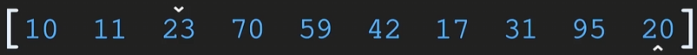

And one last thing to mention before we move on is that `we again work with indices`, just like we did with the insertion sort.`We don't loop over the elements directly, but rather the indices`. 

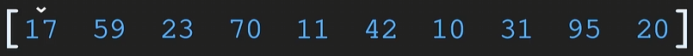

**Analogy**

Selection Sort = Picking Shoes from a Messy Pile
Now imagine you have a messy pile of shoes.
- You want to line them up from smallest to largest size.
- Each time, you select the smallest shoe from the pile and place it at the front of the line.
- Then you repeat with the remaining pile until all are lined up.
That’s selection sort: repeatedly select the smallest (or largest) item and move it into place.


Selection Sort → select the right item.

In [7]:
def selection_sort(array):
# the 1st for loop starts with current index(0),assigns the same as smallest & then uses 2nd for loop to identify the smallest & when found swap with 
# current index and then repeat the cycle with current index as 1 and continue sorting the array with the lowest at index 0
    for i in range(len(array)): # range(10) means starting from zero upto 10 but not 10 (9), which covers all 10 elements of the array
        smallest = i # current (0 to 9) index is assigned the smallest
        for j in range(i+1, len(array)): # start from next index onwards till the end, to identify smallest of the array and swap with smallest
            if array[j] < array[smallest] : # now we are comparing actual values hence using array and index reference
                smallest = j # it keeps looping till the end of the array and smallest in the array is identified and assigned to variable "smallest"
# so far only the index with smallest value is identified and only after that we swap the actual values using the smallest index identified              
        array[i],array[smallest]=array[smallest],array[i] # whichever index has the smallest element, is now swapped with intial index (0)
    return array               

In [11]:
array = [17,59,23,70,11,42,10,31,95,20]
array

[17, 59, 23, 70, 11, 42, 10, 31, 95, 20]

In [13]:
select_sort = selection_sort(array)

In [15]:
print(select_sort)

[10, 11, 17, 20, 23, 31, 42, 59, 70, 95]


#### Time And Space Complexity

Speaking of performances, what would the complexities of selection sort be?
We again evaluate the best, worst and average time output. If we analyze the code structure, we see that we have two loops.This usually means a quadratic performance, but with insertion sort, we saw that in the best case where the array was already sorted, we got a linear time performance. Can we get the same here? Unfortunately not with insertion sort. The inner loop only ran under certain circumstances with selection sort. It will run regardless of whether the list is sorted, reversed or randomized. The complexity is O(n)squared for all cases, and from the memory utilization perspective, it's still O(1) since we sort the array in place. So if we were to give selection sort of a final verdict, we can say that it's rather easy to implement, but it's quadratic time performance makes it inefficient on large arrays, and on average it's performing worse than insertion sort.

##### Time Complexity of Selection Sort

- Best Case: O(n²)  
- Average Case: O(n²)
- Worst Case: O(n²)

##### Space : O(1)

#### Practical Use Case of Selection Sort
- **Where used**: Situations with small datasets and minimal memory writes.
- **How used**: Useful when write operations are costly (e.g., EEPROM or flash memory).
- **Example**: Sorting data in embedded systems with limited write cycles.

### Bubble Sort

Bubble sort gets its name from the apparent motion of smaller elements to bubble up to the beginning of a list, as if they were lighter. Other names for this sorting method are sinking or sifting sort, because it can also be written to have the larger elements sink down to the bottom of the list. But regardless of how you want to implement it, the core logic is the same for both approaches.

For every element of the array, we need to go over all the other ones and bring the smallest one to the position we started at. **`And this scan will be done from the end of the array towards the beginning`**. And with each pass through, we compare the element we're currently at to the one before it, and if needed, we swap them

**Analogy**

Bubble Sort Analogy: Sorting Fruits in Water
Imagine you have a bucket of water with apples and oranges floating inside. You want all the apples at the top and oranges at the bottom.
- You start by comparing two fruits at a time.
- If an apple is below an orange, you swap them so the apple “bubbles up.”
- You keep doing this, pair by pair, until the heaviest fruits (oranges) sink to the bottom and the lightest fruits (apples) rise to the top.
- Each pass pushes the largest item to its correct position, just like bubbles rising in water.

Another Analogy: Sorting Books by Height
Think of a messy stack of books on a shelf:
- You look at two neighboring books.
- If the taller one is on the left, you swap them.
- You repeat this across the shelf, so the tallest book slowly “walks” to the far right.
- Then you repeat the process until all books are in order.

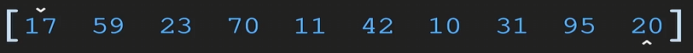

So for us we compare `20` with `95`.Since `20` is smaller, we swap them and then we compare `20` to `31`. Again `20` is smaller so we swap. Then compare `20` to `10`.This time `20` is greater than ten, so we don't swap, but the iteration will keep going. And now we compare `10` to its left neighbor `42` is greater. So we swap again. And it so happens that `10` is the smallest element in the array. So we end up bringing it all the way to the index we started at, which is `Zero`.

Since we now know that `10` is in the correct position, we move on to the next number. And we again scan the list from the end (`95`) when we reach number `20`, and we compare it to the one before it. We perform another swap. After that we reach `11`, and this one we bring forward all the way to the starting point, which notice that for the second run it's index one. We don't need to keep comparing until the beginning of the array, since we already know that `11` can't be smaller than ten, which is the number we brought to index one in the first iteration. And then we continue to the next element and repeat the entire process.

So from a technical perspective, the way we would implement this is with two loops. The main one runs one time from start to finish. This is again is the top arrow in this drawing. The second loop will go from the end of the array towards the beginning, and it stops at the same index we're currently at in the main loop. It doesn't go all the way to index zero, and inside this second loop is where we compare the element we're currently at with the one before it, and swap if necessary.

Notice that again, the array we leave behind is sorted and as we loop, we don't compare or touch in any way the elements we went over already. Similarly to selection sort.

In [15]:
def bubble_sort(array):
# 1st loop runs from left to right(top pointer),It ensures multiple passes through the array to "bubble" the largest unsorted element to the end in each
# pass. After each pass, one less comparison is needed because the last elements are already in place.
    for i in range(len(array)-1): # we don't need to loop until the last element. We can stop at the second to last one(len(array)-1)becoz when we reach
# the second to last element, the inner loop will compare it to the last element & will swap if necessary & since they're the last two elements, 
# they'll be for sure correctly sorted.      
        has_swapped = False # reseting "has_swapped" so when swap happens below we can set "has_swapped" as True and continue the loop, else we break
# range(start = total elements in array, end = where 1st loop pointer is  , step = reverse traverse (starting from right side) 
# This “backward” approach is just a design choice—it bubbles smaller elements toward the front.
        for j in range(len(array)-1, i , -1):#2nd loop(bottom pointer)runs from right to left(reverse order)& meets/ends at where 1st loop pointer is(i)
            # you can also use " for j in reversed(range(i+1,len(array))
# The array that we leave behind (from top pointer) is already sorted and as we loop we dont compare/touch in any way the elements we went over already  
            if array[j - 1] > array[j]:
                array[j - 1], array[j] = array[j] , array[j - 1]#Tuple swap syntax to exchange values.After swap smaller value moves forward in the list
                has_swapped = True # Sets the flag to True indicating that at least one swap occurred. Important for early termination logic.
        if not has_swapped: # If no swaps happened during this entire inner loop, it means the array is already sorted.
            break # So we break out of the outer loop early, saving time.
    return array

In [17]:
array = [17, 59, 23, 70, 11, 42, 10, 31, 95, 20]
array

[17, 59, 23, 70, 11, 42, 10, 31, 95, 20]

In [19]:
Bubble_sort = bubble_sort(array)

In [11]:
print(Bubble_sort)

[10, 11, 17, 20, 23, 31, 42, 59, 70, 95]


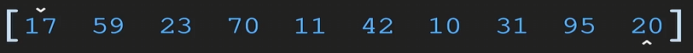

Let's say that this code will continue to run for a couple more iterations until we reach the sixth index. If we now look at the part of the array that's still to be sorted, which is from index six to the end, we notice that it's already sorted. And this is not by coincidence. **Bubble sort naturally brings all the biggest values to the end of the array, and towards the final iterations they end up sorted before we finish the entire main loop and all the inner loops we do after that would be pointless.**

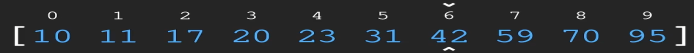

Now we can see that the list is already sorted, but our computers can't. At least not with this current implementation, and it will keep on searching. So we have to address this. What we can do is to check if we don't do any swaps, if we have one full run of the inner loop without doing any swaps, it means that all the values are already in the current position. So we can just stop the program.

Let's see how we can implement this.

What we need is a so called flag variable, which I'll define right before the second loop starts, and call it something like **"has swapped"** and set its value to false. Now, every time we do a swap, we want to update this variable to true. And then outside the inner loop. After it finishes running, we check this variable. If it's false, it means that this part of the code never ran because we never did a swap. So all the remaining values were already sorted. And what we can do is to just break out of the loop. Notice that this break statement is inside the main loop, and when this line is run, it's the main loop that stops, not the inner one. And that was it. It's a pretty simple and classic optimization to make

**has_swapped : Why do we need it & what's the use?**

This check helps **avoid unnecessary passes** once all elements have bubbled into place. In a worst-case scenario (like a reversed list), has_swapped stays True for many passes. But in a nearly sorted list, you save time with just one or two passes before has_swapped becomes **False**.

1. When sorting from right to left(using Inner loop) we are making sure the lowest values bubble out (move to the left most) and in the process the highest values get pushed to the right, however many times while we have reached the middle or close to the end index, the right corner is already sorted by default.
2. To save time and to optimize we are using has_swapped flag.
3. So we use has_swapped= True for inner loop to confirm that swaps happened during the current pass and once the pass is complete it is reset to False in Outer loop, so we can capture again during inner loop
4. Let's assume we have an array of 10 elements and during pass Pass 7(like below) the rest of the elements in the right are already sorted in place, hence when the comparison happens there won't be any swaps and the flag has_swapped which was reset to False, will remain the same 
5. At this point the next code inline "if not has_swapped" gets activated and breaks out of the code, 


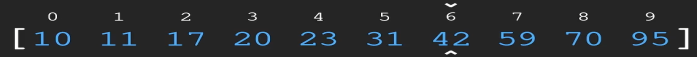

6. The break statement **exits the outer for i in range(...) loop**, even if i hasn’t reached the maximum value.
    - So if it's triggered during **Pass 7 (i = 6)**, the loop doesn’t continue to i = 7, 8, etc.
    - Control jumps to whatever comes **after the loop**—which in this case is: return array

#### Time And Space Complexity

So let's now talk about performances. In the best case scenario, this function will run in linear time. We traverse the list only once with the inner loop. Because we have this optimization in place, we stop after we notice we didn't do any swaps. The old version of bubble sort would not run in O(n) time, because it will never know that the list is sorted and the inner loops will run normally, even if we didn't move any values. You can see how important this change we made is to the performance of this method. The average in worst cases, though, are O(n) squared. 

At the end of the day we have two loops, one inside the other, and we can't escape the quadratic time which comes with that. The space complexity is O(1), just like the other ones. We sort the array in place so no extra memory is used. So as a final verdict for bubble sort, you might think it's not that bad, right? I mean, it has the same performance as insertion sort and it's easy to implement. But the reality is that even though the runtime is mathematically the same bubble sort is proven to be considerably slower than insertion sort. And that's due to the large number of comparisons and swaps it has to do, even in the optimized version. Some people in the industry have even recommended removing bubble sort from learning materials in schools and universities due to its inefficiency. But it's still quite popular due to its simplicity and it's still thought provoking when you're new to algorithms

##### Time Complexity of Bubble Sort

- Best Case: O(n)  
- Average Case: O(n²)
- Worst Case: O(n²)

##### Space : O(1)

#### Practical Use Case of Bubble Sort
- **Where used**: Educational purposes, simple demonstrations.
- **How used**: Rarely used in practice due to inefficiency, but good for teaching algorithm basics.
- **Example**: Introductory programming courses to illustrate swapping and iteration.

### Shell Sort

The three algorithms we just learned were relatively easy to implement in terms of code length and also the logic behind them. But they also have a major shortcoming. They're only effective for small to medium sized arrays because of their quadratic time complexity. Sorting large arrays with them can become very time consuming, very fast. And this led plenty of computer scientists to develop sorting methods that improved on the O(n) squared runtime. These algorithms are generally more complex, and they might take a bit more time to understand and more skilled to implement, but they're very useful and are quite popular in interviews


One of the main problems that caused the previous sorting algorithms to run slow on large arrays was that a lot of times we had to move items along distance from their starting position to their final sorted one. And we did that with a lot of comparisons and a lot of swaps. For this reason, there were many solutions developed which tried to do less comparisons and move data over long distances in the array more efficiently. One of these solutions achieved that by sorting only a part of the array first, and then sorting another subset, and kept going until it ended up with an array whose elements are closer to their final position, and thus making it faster to sort than what we started with.

The solution we're about to learn is also called diminishing increment sort, but it’s better known as the Shellsort, named after the computer scientist Donald Shell, who designed it in
To better understand this sorting method, let's recall that with all the previous algorithms we learned, we were comparing a certain item to the one right next to it and then swap if necessary. Except of course for selection sort, which didn't swap with every comparison. Shellsort starts off by sorting items that are a certain distance apart, and then decreases that distance until it becomes one.

So let's say we start with a gap of **`5`** array indices. This means that we compare `42` to `17`.  Do we need to swap? No. So we keep moving forward, preserving the gap of five indices between the numbers. And now we compare `10` to `59`. Since `10` should come before `59` we swap them. And then we keep going. `31` and `23` No need to swap here. Now `95` and `70` again. No swap. And finally `20` and `11` and we reached the end of our array. So after this first run is done, we can't really say that we have a sorted array, but we did bring some elements closer to their final position.

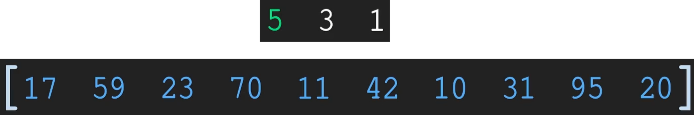

And now we choose a smaller gap like **`3`**, and we start again from the beginning of the array, comparing the elements with a gap of **3** indices `70` and `17`.No need for a swap `11` and `10` again No swap`42` and `23` Same here. `59` and `70`, This time we do need to swap, but there is a catch.
After we do it, we don't stop here. We now want to compare the position we just swapped to the one `3` indices lower. So we want to keep comparing `59` to `17`, because we can't know for sure that they are in the correct position after we did the initial swap. And normally we would keep going `3`  indices lower again, but we're already at the first position in the array. So we stop here with comparing and continue with the next set of numbers. `31` and `11` ,No swap needed. And since this time we didn't do a swap, we don't need to compare `11` with the one `3` indices down, which will be `10` because we already compared them a few moments ago.
Some keen observers might notice that what we're doing here resembles insertion sort. The reason for that is because, well, we are doing insertion sort. The only difference is that unlike insertion sort, we are comparing and swapping items with a larger gap between them

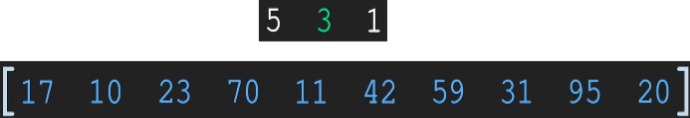

`95` & `42` are placed correctly .So we go to the next one `20` & `70` ..This time we need to swap. And after that we need to compare it to the one **3** indices before it, which is `59`.And now we have to swap again (`59` with `20`).And we keep going. Compared `20` to the `3` indices down the list, which is `17`.No swap needed. And we're done with this second iteration. You might notice that our array is starting to be more ordered. It's not sorted just yet, but we now have most of the smaller numbers in the first half of the array and the larger ones in the second half. And in the last iteration, we compare the elements with a 1 index gap.

If you remember when we talked about complexities, we mentioned that insertion sort is pretty good for an almost sorted array. Well, with Shellsort we take full advantage of that because when we reach the last iteration, our array will be close to sorted because of all the previous runs. And that's shellsort. It's basically an insertion sort done with steps.


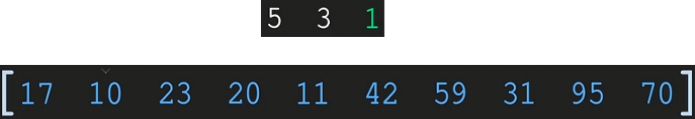

We first sort items with a large gap between them. Then we keep closing that gap until the last run, where items will be **`1`** index apart, by which point the array will be almost sorted, thus making the last run more efficient. And I want to mention that there are some versions that use a different type of base sort like selection or bubble, but the preferred choice and the one originally developed by the author is insertion sort

**But the next important question would be why these gaps 5, 3 and 1?**

Can't we use another sequence of numbers? Well, sure we can. And there were many alternatives proposed over the years, but unfortunately a clear cut answer as to which is best can't be given that easily. It has been proven, though, that using any sequence will give better results compared to the simple insertion sort, as long as that sequence satisfies the most important condition of having the last gap equal to one.

The Basic concept here is to maintain a gap of **5-3-1**(based on for loop condition) between preceding and succeeding elements using gap variable and keep comparing if the one on the right is smaller than the one on the left(preceding), if it is, then swap takes place and it doesn’t stop there, now you go back and find a new preceding elements which is (**5-3-1**) gaps behind to compare if your new j value needs to go further left or stay where it is.

So let's assume we have above list and i is `9(20)`, so now we identify j(i-gap) which is `9-3=6` , so j = `6(70)`, now we run the code => `while array[j+gap] < array[j]`, which results in original i value `9(20)` which is lesser than its left value j which is `6(70)`. That’s true, so swap happens `70` shifts right to index `9` and `20` moves to left index `6`, now j's new value at index `6` is `20` and now after the swap we have to check if `20` is still higher than its preceding element(`3 gaps behind`), so we update j by subtracting with the gap(`3`) to shift `3` indexes behind to compare with index `6(20)`, which would be (`6-3 = 3`) Index `3(59)`, so will run the while loop again and the 1st criteria is true `array[j+gap] < array[j]`, and also  since `j >=0` (which is 2nd criteria in while loop) we execute the swap again, `20` replaces `59` in index `3` and j is once again updated to shift 3 steps back at index 0(`j=3-3=0`), which is `17` and we are back in while loop to find a succeeding element 3 gaps away which is obviously `3(20)` using the formula j+gap

In [15]:
def shell_sort(array):
    gaps = [ 5, 3, 1]
# A predefined sequence of gap values used to separate comparisons.These determine how far apart the elements compared and shifted will be.
# Starting with a larger gap allows quick movement toward a more sorted list.
    for gap in gaps : # Iterates over each gap value, starting with the largest.
# Each pass with a different gap helps refine the sorting until we reach a gap of 1 (essentially an insertion sort).
        for i in range (gap , len(array)): # This ensures each element has a previous element gap positions before it to compare against.
            j = i - gap # - Sets the pointer j to compare the element at index i with the element that is gap positions behind.
            while array[j+gap] < array[j] and j >= 0: # - While the later element is less than the earlier one and j is a valid index:
                array[j+gap], array[j] = array[j], array[j+gap]
                j -= gap # - Steps backward by the gap, continuing to compare earlier elements in the same gap group.
    return array            

In [23]:
array=[17,59,23,70,11,42,10,31,95,20]
array

[17, 59, 23, 70, 11, 42, 10, 31, 95, 20]

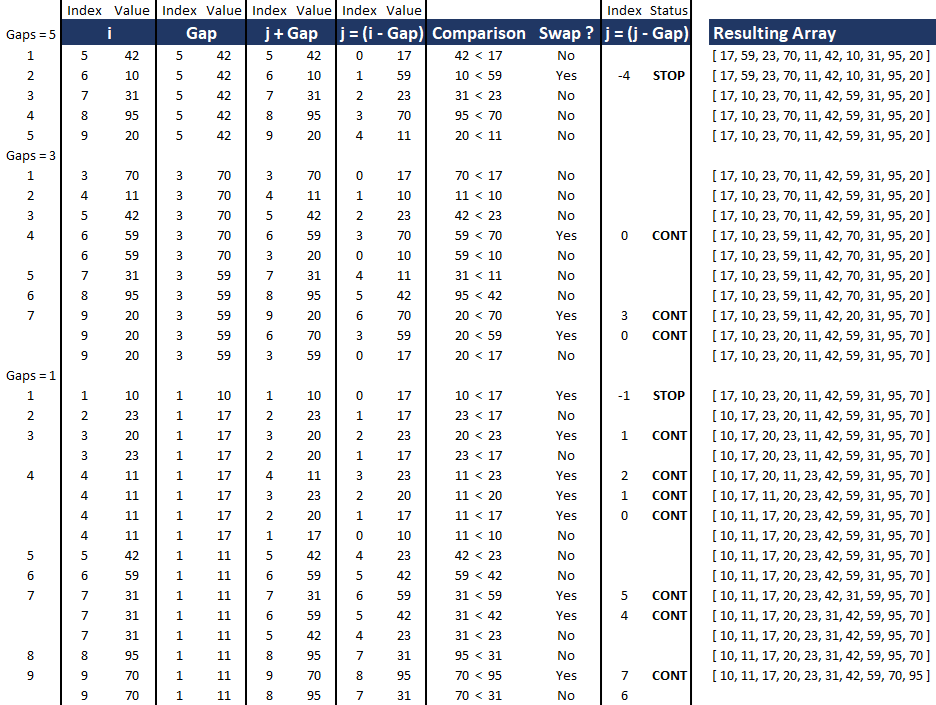

In [167]:
def shell_sort(array):
    gaps = [ 5, 3, 1]
    for gap in gaps :
        for i in range (gap , len(array)): 
            j = i - gap
            print(f"Gap={gap}  |  i = {i}  |  [j+gap] = [{j+gap}]{array[j+gap]}  |  j = [{j}]{array[j]}  |  Comparison : if {array[j+gap]} < {array[j]}  : {array}")
            while array[j+gap] < array[j] and j >= 0:
                print(f"====== {array[j+gap]} < {array[j]}  |  Swap = Yes  |   Updated j = [{j}]{array[j]}  |   Updated Array : {array} =====")
                array[j+gap], array[j] = array[j], array[j+gap]
                j -= gap
    return array            

In [169]:
array=[17,59,23,70,11,42,10,31,95,20]


In [171]:
ss=shell_sort(array)
ss

Gap=5  |  i = 5  |  [j+gap] = [5]42  |  j = [0]17  |  Comparison : if 42 < 17  : [17, 59, 23, 70, 11, 42, 10, 31, 95, 20]
Gap=5  |  i = 6  |  [j+gap] = [6]10  |  j = [1]59  |  Comparison : if 10 < 59  : [17, 59, 23, 70, 11, 42, 10, 31, 95, 20]
====== 10 < 59  |  Swap = Yes  |   Updated j = [1]59  |   Updated Array : [17, 59, 23, 70, 11, 42, 10, 31, 95, 20] =====
Gap=5  |  i = 7  |  [j+gap] = [7]31  |  j = [2]23  |  Comparison : if 31 < 23  : [17, 10, 23, 70, 11, 42, 59, 31, 95, 20]
Gap=5  |  i = 8  |  [j+gap] = [8]95  |  j = [3]70  |  Comparison : if 95 < 70  : [17, 10, 23, 70, 11, 42, 59, 31, 95, 20]
Gap=5  |  i = 9  |  [j+gap] = [9]20  |  j = [4]11  |  Comparison : if 20 < 11  : [17, 10, 23, 70, 11, 42, 59, 31, 95, 20]
Gap=3  |  i = 3  |  [j+gap] = [3]70  |  j = [0]17  |  Comparison : if 70 < 17  : [17, 10, 23, 70, 11, 42, 59, 31, 95, 20]
Gap=3  |  i = 4  |  [j+gap] = [4]11  |  j = [1]10  |  Comparison : if 11 < 10  : [17, 10, 23, 70, 11, 42, 59, 31, 95, 20]
Gap=3  |  i = 5  |  [j+ga

[10, 11, 17, 20, 23, 31, 42, 59, 70, 95]

**Why j >= 0 Matters**

When the loop iterates through the array:
   - j starts as i - gap, which moves backwards as j -= gap is executed.
   - Without checking j >= 0, you risk accessing array[j] when j becomes negative — which would lead to index errors or unexpected behavior, especially in Python where negative indices wrap around to the end of the list.

`Protective Function`
   - It ensures the loop only runs while j is within valid bounds (i.e., still inside the list).
   - Prevents infinite loops or accidental swaps with unrelated elements.

`Combined Logic`

while array[ j + gap ] < array[ j ] >= 0 :

says: "Keep swapping as long as the element ahead is smaller and you're not off the edge of the list.” 
This keeps the traversal and sorting logic tight and safe


**Why array[ j + gap ] Works**

Here’s the full logic:
   - i starts at gap, moves forward.
   - j = i - gap, which points to the element gap steps before.
   - array[j + gap] is actually just array[i], since j + gap = i.
   - The loop `swaps elements if the one at i is smaller than the one gap positions before it` (array[j]).
   - Then it moves j backward and checks again: are earlier elements also larger than array[i]?
So you're essentially doing a `gap-based insertion sort`, nudging the smaller element toward its rightful spot by shifting larger elements forward.


**Big Picture**

The goal is to:
 - Compare and rearrange elements that are far apart initially.
 - Progressively reduce the gap to refine the order.
 - Final pass with gap = 1 acts like insertion sort, now with fewer inversions to fix.

j -= gap is what lets Shell Sort "leap backward" through the array within the same `gap group`, essentially mimicking insertion sort logic but spaced apart. Here's why it matters:

`Why Use j -= gap`

This line pushes the loop backward to keep comparing earlier elements in the same group, like a time traveler scanning previous moments:
   - You're checking if the current element (array[j + gap]) still needs to move further left.
   - If earlier elements (array[j]) are still larger, you keep shifting them forward.
   - This allows the algorithm to “bubble” the smaller value through the entire gap segment.

`Visual Analogy`

Imagine you’re sorting books on a shelf spaced out by 5 slots:
   - You pick up a book at slot i, look 5 slots before (j = i - gap), and ask:
“Is that one bigger?”
   - If yes, you swap and step back again (j -= gap) — “What about 5 slots before that?”

It’s the mechanism that lets Shell Sort work through long-range corrections, and progressively refine toward perfect order.

`Without j -= gap?`

You’d only swap once per element, leaving misordered elements behind.
That would reduce Shell Sort to a shallow version of insertion sort with gaps — inefficient and incomplete.

#### Time And Space Complexity

Let's talk about the performance of Shellsort. We said in the beginning that it was developed as a better alternative to the basic sorting methods that ran in O(n) squared time. But is it really better? I mean, we have here three loops, one inside another, which normally can't be good, right? Well, just like how we couldn't give a concrete answer for which gap to use, we can't give a clear explanation of what are the best, worst, and average performances. At least not without counting operations and swaps and doing some serious calculations. We can easily tell that the space complexity is linear since we sort in place, but the time complexity ranges from O(nlogn) to O(n) squared, and everything in between. 

#### Time Complexities

- $O(n \log n)$  
- $O(n^{4/3})$  
- $O(n^{3/2})$  
- $O(n \log^2 n)$  
- $O(n^2)$  

#### Space Complexity
- $O(1)$

#### Practical Use Case of Shell Sort
- **Where used**: Medium-sized datasets where quicksort/merge sort overhead is undesirable.
- **How used**: Improves insertion sort by allowing exchanges of far-apart elements.
- **Example**: Early implementations of sorting in libraries before quicksort became dominant.

### Heap Sort

Although shellsort was an improvement over the basic insertion selection and bubble sorts, it still didn't achieve the best possible performance of a sorting algorithm, we'll have a look at methods that perform considerably better, even on larger arrays
The name heap should sound familiar. We discussed it in detail when we learned about the tree data structure. The concept of heap and everything that comes with it, like how data is stored, what's the method of building a heap, and how we preserve the heap structure. They are all strong requirements for understanding heap sort. 

Heaps are actually kept in memory as lists with their elements organized in such a way so that the value of each element is larger than the values of both its children.  This will essentially make the top number the biggest one in the collection. This is, of course, if we have a max heap, A min heap will be the opposite, with the smallest element at the top of the heap. And the logic behind this sorting method will be similar for both types of heaps.

Heap Sort is a slick and efficient comparison-based sorting algorithm that uses a data structure called a heap—specifically a binary heap. It’s particularly great for sorting large datasets, as its time complexity is consistently `O(n log n)`, regardless of the input order.
Here’s how it works, broken down into clean stages:

**Key Concepts**
  
    - A heap is a special kind of binary tree where: 
		○ In a max heap, each parent node is greater than or equal to its children.
		○ In a min heap, each parent is less than or equal to its children.
	- Heap Sort typically uses a max heap for ascending order sorting.


**Step-by-Step: How Heap Sort Works**
    
  1. Build a Max Heap from the input array.
     - The largest element will be at the root of the heap.
  3. Swap the root (maximum value) with the last element of the array.
     - This puts the largest value at the end of the sorted array.
  5. Reduce the heap size by one.
     - Exclude the last element from the heap (it's in its correct position).
  7. Heapify the root again.
     - Restore the heap property by rearranging the heap.
  9. Repeat steps 2–4 until the heap is reduced to size 1.
     - By the end, the array is sorted in ascending order.

Heap Sort is `in-place`, doesn’t require extra memory, and is not stable (meaning it doesn’t preserve the relative order of equal elements). Still, for scenarios where memory matters and predictable performance is key, it’s a solid pick.

**Steps in Detail**

Original Order

1. So, the first line to be executed will be Heapify(array), which will invoke the Heapify function and create a heap out of our initial array.


2. Now that we have the largest number at position `[0]95`, we proceed to the for loop, which will start running from the last index(`[9]11`) towards the first (`[0]95`). At the first line, we swap the element at index zero with the one at the current end index. In the first iteration, this variable will be [`9`], so we swap `95` with `11`.

3. After swapping we call the `move down function` not on the entire list, but on a subset of it, leaving out the last index(`[9]95`).This will basically rearrange the elements of this subarray in a heap fashion.

4. The loop will then update end_idx to be `8`, and now we swap the element at index `[0]70` with the one at the new end index(`[8]17`) so we don't touch `95` anymore

5. Move_down function  will then create a heap out of the remaining numbers except `70` and `95`.

6. End_idx will be updated again by the loop as `7`, and the same procedure will repeat over and over on all the remaining elements. Now , Index `7, 8, 9` will be untouched while rest of the elements are sorted from Highest to Lowest as highlighted below.

Notice that the remaining unsorted subarray gets smaller and smaller with each iteration, and the part we leave behind, the one that is sorted keeps growing.

7. When End_idx is finally 1, we do the swap with the element at index `0`.And when the loop stops, we don't want to update the End_idx to be zero, because the move down function will then run from index `0` to index `-1`, which is the entire array. And we definitely don't want that because as you can see, the array is now sorted by the end of move_down function. We return the array and that's it.

In [7]:
''' Declares the main sorting function. Accepts a list array to sort in-place'''
def heap_sort(array):
    heapify(array)
    for end_indx in range(len(array)-1,0,-1):
# Iterates backward from the last index to 1. At each step,the largest element (at root,index 0) is placed at the end.
        array[0], array[end_indx] = array[end_indx], array[0]
# Swaps the root (max value) with the current last element. Effectively places the largest value at its sorted position.
        move_down(array, 0, end_idx - 1)
# After swapping, restores heap structure in the reduced array (excluding the sorted tail)

# refer to Heapify Algorithm from Heaps(2.9)Section for details
'''Converts array into a max heap, where every parent is greater than its children.Begins by feeding the last node(of subtree) that is not a leaf (11) & 
then uses movedown fn to create max heap and then move on to next subtree parent(70,23,59,17) to check if any of its children are greater than it'''
def heapify(array): # Begins construction of the max heap.
    last_nonleaf_idx = len(array) // 2 - 1 #Finds the index of the last parent node(everything after this is already a leaf.last_nonleaf=10//2=5-1= 4(11)
    for i in range(last_nonleaf_idx, -1, -1):#Iterates backward from the last parent to the root.Each node is heapified individually.(i = 11,70,23,59,17)
        move_down(array, i, len(array) - 1) # Calls move_down to sink the current node so that the subtree rooted at i satisfies the max heap property.
    return array # Optional return of the heapified array (not used in heap_sort but allows inspection)
    
'''Defines a helper to sink an element down the heap, checks if Parent has max value than children, if not shuffle first with left & then right child'''
def move_down(array, start_idx, end_idx):# gets the array, parent index , 9 (10 elements array -1) as input
    child_idx = 2 * start_idx + 1 # Computes the left child index of start_idx. child_idx = 2 * 4+1 = 9 (20) , which is 11's child 
    while child_idx <= end_idx: # While a child exists within bounds, continue heapifying downward
        if child_idx < end_idx and array[child_idx] < array[child_idx + 1]:#since 9 is the last index,there are no right child to check,we skip this loop
# Checks if there’s a right child and whether it's greater than the left. If so, prefers the right child
            child_idx += 1 # Updates to right child if it's larger
        if array[start_idx] < array[child_idx]: # Compares the parent with the larger child. If child is bigger, swap.(if 11 < 20 => swap)
            array[start_idx], array[child_idx] = array[child_idx] , array[start_idx] # Performs the swap so that parent moves down.
            start_idx = child_idx # Updates parent index to where the child was. Continue sinking. start_idx = 
            child_idx = 2 * start_idx + 1 # Recomputes left child index for the next loop iteration.
        else : 
            break


                     17
                   /    \
                59       23
               /  \     /  \
            70     11  42   10 
           /  \   /
         31   95 20                       

[ 17,   59,  23,  70,  11,  42,  10,  31,  95,  20 ]

**Why Max Heap is Used for Ascending Order?**

- `Heap Property:`
   - A `max heap` ensures the largest element is always at the root.
   - By swapping the root with the last element and shrinking the heap, we place the largest element at the end of the array.
   - Repeating this process naturally builds the array in `ascending order` from back to front.
       
- `Efficiency:`
   - Each extraction (root swap + heapify) gives us the next largest element in O(logn).
   - The algorithm doesn’t need extra storage—it sorts in place.

**Why Not Just Use a Min Heap?**

- A `min heap` keeps the smallest element at the root.
- If we tried to sort ascending with a min heap:
  - The smallest element would always be extracted first.
  - To build ascending order, we’d have to place it at the beginning of the array.
  - But heap sort works by filling from the end of the array downward (to avoid overwriting unsorted elements).
  - Using a min heap would force us to either:
     - Write elements sequentially into a new array (breaking in-place sorting), or
     - Do extra shifting operations (inefficient).
   

**Summary**
- `Max Heap` → `Ascending order`(largest to smallest, placed at the end).
- `Min Heap` → `Descending order` (smallest to largest, placed at the end).
- Heap sort is designed around in-place sorting, so max heap is the natural choice for ascending order.

`Bottom line`: You could use a min heap, but it would either give you descending order or require extra space/operations to rearrange elements. The max heap approach is elegant because it sorts in place with no extra memory.

**Additional Explaination on What happens with a min heap**
- A `min heap` guarantees the smallest element is at the root.
- If you keep extracting the root one by one, you’ll indeed get the elements in ascending order.
- But here’s the catch: those extracted values don’t automatically line up inside the same array in sorted order. Heap sort’s design is in-place—it doesn’t use an extra array to store the sorted sequence.
So if you just build a min heap and stop, the array is not sorted. It’s only heap-structured (which is different from sorted). For example:
Your array after building a min heap might look like:

**[10, 11, 17, 20, 59, 42, 23, 31, 95, 70]**

**Updated algorithm to track control flow and output**

In [109]:
array = [23,44,11,27,54,35,13,61,22,48,41,39,52,17,65]
array

[23, 44, 11, 27, 54, 35, 13, 61, 22, 48, 41, 39, 52, 17, 65]

In [111]:
def heap_sort(array):
    heapify(array)
    for end_idx in range(len(array) - 1, 0, -1):
        # Swap root with last element
        array[0], array[end_idx] = array[end_idx], array[0]
        print(f"Extract max | swap root with index {end_idx} | array={array}")
        move_down(array, 0, end_idx - 1)
    return array


def heapify(array):
    last_nonleaf_idx = len(array) // 2 - 1
    for i in range(last_nonleaf_idx, -1, -1):
        move_down(array, i, len(array) - 1)
    print(f"After heapify: {array}")
    return array


def move_down(array, start_idx, end_idx):
    child_idx = 2 * start_idx + 1
    while child_idx <= end_idx:
        right_child = child_idx + 1 if child_idx + 1 <= end_idx else None

        # Build one single debug line BEFORE swap
        debug_line = (
            f"start[{start_idx}]={array[start_idx]} | "
            f"left[{child_idx}]={array[child_idx]} | "
            f"right[{right_child}]={array[right_child] if right_child is not None else None} | "
            f"before={array}"
        )
        print(debug_line)

        # Choose larger child
        if right_child and array[child_idx] < array[right_child]:
            child_idx = right_child

        # Swap if needed
        if array[start_idx] < array[child_idx]:
            array[start_idx], array[child_idx] = array[child_idx], array[start_idx]
            print(
                f"swap {array[child_idx]} <-> {array[start_idx]} | after={array}"
            )
            start_idx = child_idx
            child_idx = 2 * start_idx + 1
        else:
            break

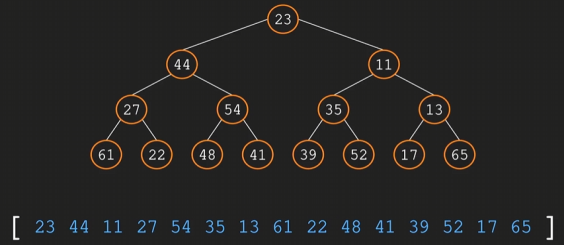

In [114]:
hp=heap_sort(array)

start[6]=13 | left[13]=17 | right[14]=65 | before=[23, 44, 11, 27, 54, 35, 13, 61, 22, 48, 41, 39, 52, 17, 65]
swap 13 <-> 65 | after=[23, 44, 11, 27, 54, 35, 65, 61, 22, 48, 41, 39, 52, 17, 13]
start[5]=35 | left[11]=39 | right[12]=52 | before=[23, 44, 11, 27, 54, 35, 65, 61, 22, 48, 41, 39, 52, 17, 13]
swap 35 <-> 52 | after=[23, 44, 11, 27, 54, 52, 65, 61, 22, 48, 41, 39, 35, 17, 13]
start[4]=54 | left[9]=48 | right[10]=41 | before=[23, 44, 11, 27, 54, 52, 65, 61, 22, 48, 41, 39, 35, 17, 13]
start[3]=27 | left[7]=61 | right[8]=22 | before=[23, 44, 11, 27, 54, 52, 65, 61, 22, 48, 41, 39, 35, 17, 13]
swap 27 <-> 61 | after=[23, 44, 11, 61, 54, 52, 65, 27, 22, 48, 41, 39, 35, 17, 13]
start[2]=11 | left[5]=52 | right[6]=65 | before=[23, 44, 11, 61, 54, 52, 65, 27, 22, 48, 41, 39, 35, 17, 13]
swap 11 <-> 65 | after=[23, 44, 65, 61, 54, 52, 11, 27, 22, 48, 41, 39, 35, 17, 13]
start[6]=11 | left[13]=17 | right[14]=13 | before=[23, 44, 65, 61, 54, 52, 11, 27, 22, 48, 41, 39, 35, 17, 13]
swa

#### Time And Space Complexity

Let's now discuss complexities. At a first glance, Heapsort doesn't look that efficient. We have to create a heap with every run of this for loop. That seems like a lot of data moved around with every iteration. But remember what was the complexity of move down and in general, the operations we do on a binary tree, it was `O(logn)`. So even if our heap grows to be very large, the move down function will not do that. Many comparisons and swaps `O(logn)` is an absolutely great performance. But we also have a regular loop which goes over basically all the elements of the array, and that is an `O(n)` action. So we have one iteration that is `O(n)`, and inside it we do an `O(logn)`action. So this entire for loop is an `O(n)` times log n complexity. 
 
**And what about the Heapify function?**

Recall from the heap chapter that this is an `O(n)` performance, because we have to iterate over almost half the elements of the list in order to create a heap out of it. So, what we have for the entire heapsort function is `O(n)` for the heapify plus `O(nlogn)` for the for loop. When we approximate that, we take the bigger of the two, which is `O(nlogn)`, and that's the final time complexity of Heapsort. And it's the same for all the cases. Best, worst and average. Whether our initial array is already sorted, reversed, or just random, our function will still need to create a heap out of it and then sort it step by step. **And that's one disadvantage of heap sort. It doesn't recognize that a list is already sorted, and it will actually break it apart and make it a heap and then sort it back**.  But the average and worst case is more than make up for it. **This is the best performing algorithm we learned for large arrays so far, by quite a margin.**

 A small note here. These are all complexities for arrays with distinct elements. In the extreme case where they're all identical, Heapsort will run in `O(n)` time since moved down will never do any swaps. But that's a highly unlikely situation, and it's usually not taken into consideration when talking about the performance of Heapsort.
 In terms of the memory utilization of our function. That is a constant `O(1)`. Everything is done in place. We don't create any additional arrays; we just sort the same one we got as a parameter when invoking the function.

Some people consider it an improved selection sort, in the sense that they both perform a scan of the array to find the smallest element, or the largest in the case of heapsort, and then place it in the correct spot. And they both work on a subset of the array that's not sorted, which shrinks with each iteration. Whether you prefer to think about it like that or not, that's up to you. We believe Heapsort is an ingenious solution which makes use of a data structure you wouldn't normally expect to see in sorting, and on top of that, it performs really well in most situations

##### Time Complexity of Heap Sort

- Best Case: O(nlogn)  
- Average Case: O(nlogn)
- Worst Case: O(nlogn)

##### Space : O(1)

#### Practical Use Case of Heap Sort
- **Where used**: Large datasets, priority queues.
- **How used**: Guarantees O(n log n) performance, useful when memory is tight.
- **Example**: Scheduling tasks using a priority queue in operating systems.

### Merge Sort

Merge sort is the first sorting algorithm we'll learn that makes use of a programming design paradigm called **Divide and Conquer**. This type of approach attempts to solve a problem by breaking it down into smaller sub problems, and then breaking those down into even smaller ones, and so on, until we are left with a problem that can't be divided any longer and is simple enough to be solved directly

We take the initial array and split it into more pieces. **Usually it's split in half, so we end up with two sub arrays**. So you might be asking yourself, now, how long are we going to do this for? Is this enough? Can we even go any further? Should we have stopped earlier? Recall the definition of divide and conquer from a minute ago. We break a problem into smaller subproblems until they can be solved directly. 

What is the problem we want to solve?

We want to sort an array. So if we keep on breaking it apart into smaller and smaller ones, 

when can we consider our problem solved? Well, ask yourself this do we reach a point when the resulting arrays are sorted? 

And the answer is yes, we do all these arrays we ended up with, which have only one element in them, are by definition sorted. **An array with only one element in it is always sorted. Therefore, we can stop splitting them when they reach the length of one**

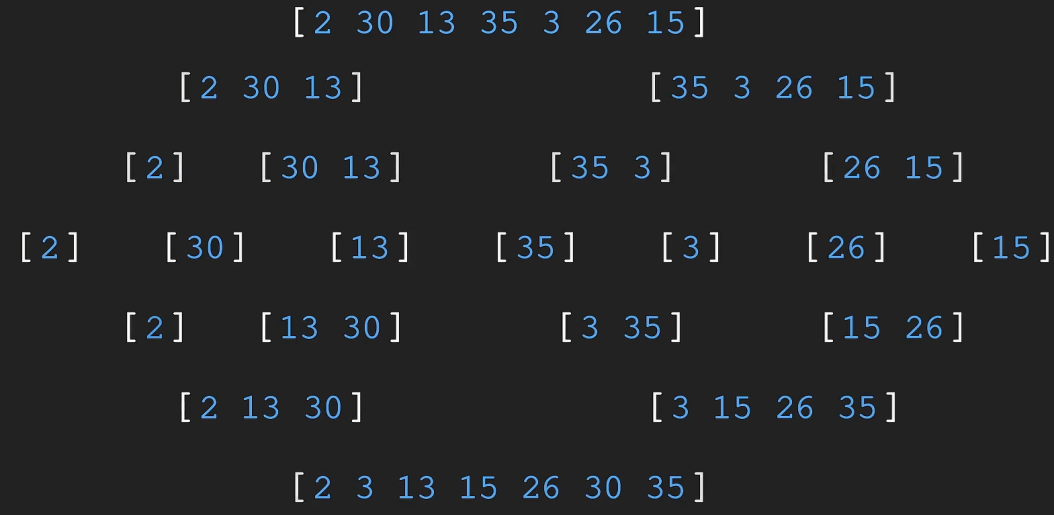

Okay, so we divided our initial array into many one element arrays. What now? Now we have to piece them back together, and not in any random way, but in a sorted fashion. And we do that by reconstructing the same arrays from which the elements came from in a sorted manner. So we take the array with the number `2`.That did not come from any bigger array. It was by itself. So we leave it like this. 

Then we take `30` and `13`.They both came from the same initial array. So we pieced them back together, but this time in a sorted fashion. And we do that with all the one element. Lists `35` and `3` will be put together and so will `26` and `15`.And then we keep going to `13` and `30` all came initially from the same array. So we recreate that array but this time sorted. Likewise with the ones from the right. Lastly, we have two final arrays which are sorted and when we put them together, we get the final result

At this point, I guess you're thinking this looks quite complicated and has some questions about how we're going to achieve all this. So let's take it step by step. First of all, what you see here is a bird's eye view of the algorithm. But this is not the correct order of how things are going to happen.


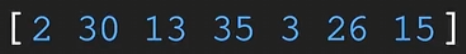

We first have to initialize an empty array to store our numbers. And then we define two variables that correspond to indices, one for each of our sub arrays, which will both start at zero(`2 & 3`).

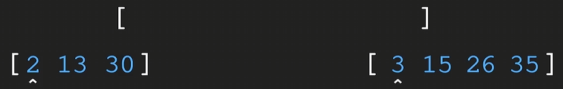

And we check the values at those indices. In the first run, we check `2` and `3`. Since `2` is smaller, we add it in the final array (empty array). After that, we want to increase the pointer of the left array by one (`13`). But we don't increase the right one just yet, because we can't know for sure if the first element of the right half (`3`) is either smaller or larger than the one from the left array (`13`). Instead, we compare again the elements at the two new indices. The left one is `13` and the right one is `3`.`3` is smaller, so we add it to the results array (empty array). 

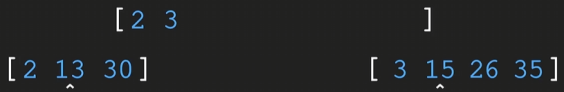

Since we added `3`, we must now increase the pointer of the right array by one (`15`) and we compare again. Both pointers are now at index one. And because `13` was an element of the left array, we increased the left pointer by one(`30`)

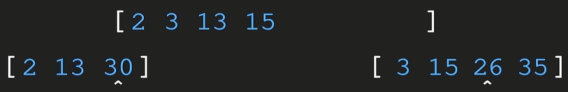

Remember, **with each iteration, we only move the pointer of the array that contained the smaller element, the one we added to the final array**. And now, after another comparison, `15` will be added to the list and we move the right pointer (to `26`).

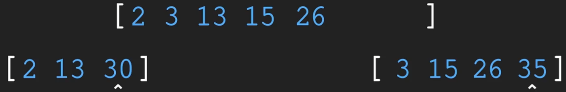

We compare one more time. `26` is the smaller one , so we push `26` into the result array and increase the index value in right sub array(to `35`). 

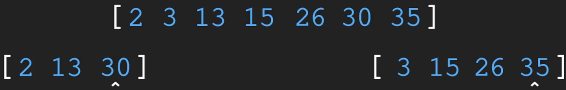

We're now at the last elements of both sub arrays. Comparing the two will result in `30` being added to the final list, and we've now exhausted the left array. When this happens, regardless of which one finishes first, we just take all the remaining elements from the other array and add them to the resulting array in the same order they're in. In our case, we only had `35` left, but if we had more we would add them all. So that's how we take two sorted lists and merge them into a single one.

Okay, so if you want to attempt this by yourself, you need to write a main function where you recursively break the input array into two halves, with the exit condition being the length of the array to be one or less, and then write a helper function that performs this union of two sorted arrays into a single one, and call it on the two halves of the input array, and then return the result of the helper functio.


In [19]:
def merge_sort(array): # 1st rule of recursion fn is to have base case, when a condition is hit,we stop the recursive course
    if len(array) < 2 : # base case condition, exit when elements in array is 1 or 0
        return array
    first_half = merge_sort(array[:len(array)//2])# Slicing Array to start from index 0 onwards and ending before the middle of the array (len(array)//2)
    second_half = merge_sort(array[len(array)//2:])# Second half gets the elements starting from middle till end of the array
    return merge( first_half, second_half )  # Helper function 
    ''' Merge the subarrays into a single sorted Array'''
def merge(first_half, second_half): # accept 2 halves as input and merge them as a single unit
    result = [] # creating an empty array
    i = j = 0 # initializing 2 variables for both halves and index(0) assigned to both, to start with
    ''' Run until one of the 2 sub arrays are depleted, thats why used "and" condition '''
    while i < len(first_half) and j < len(second_half): # 
        if first_half[i] < second_half[j]:
            result.append(first_half[i])
            i += 1 # incrementing index value once lowest value is added to result array
        else :
            result.append(second_half[j])
            j += 1
    ''' Once one of the SubArray runs out of all its elements (from above while loop), we now need to finish the remaining elements left.
    Also we wont know which one of them finishes first, hence we are checking both '''
    while i < len(first_half): # executing this section means first_half still has elements that we didnt verify with the if condition above 
        result.append(first_half[i]) # since second_half doesnt have any more elements, we dont need to compare with anything to append
        i += 1
    while j < len(second_half):
        result.append(second_half[j])
        j += 1
    return result

In [21]:
array = [2, 30, 13, 35, 3, 26, 15]
array

[2, 30, 13, 35, 3, 26, 15]

In [23]:
ms=merge_sort(array)

In [25]:
print(ms)

[2, 3, 13, 15, 26, 30, 35]


**Control flow for `merge_sort`**

**Control flow for `merge`**

#### Time And Space Complexity

How do we approximate the complexities of such a function? We have recursive calls.We have iterations,we create new arrays.We have a lot going on.So let's take it step by step, starting with the time performance.

**Time performance:**

Our algorithm starts off by dividing our input array in half. So the first question is, will this action require more time as the input grows in size, or is it constant time?

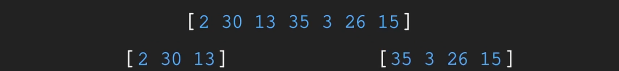

What we do is we just take the middle index of the array and split it in half. We don't do any iteration over the array or anything like that.So this action alone is a linear time operation.And we continue doing that until we can't divide any longer.

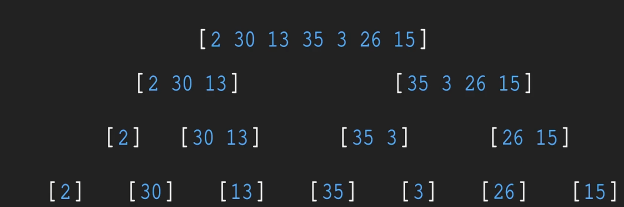

Now we get to the second part of the algorithm, and that is merging the arrays into sorted ones. We had to go over both arrays from one element to the next one, compare them and put them in new ones.

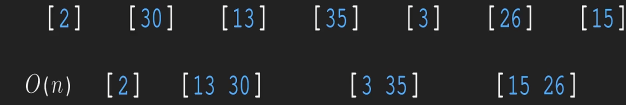

So in this first phase of merging, we have to go over all the elements of the input array, and that is an O(n) operation. It grows proportionally to the size of our input

We then continue to the next step, which is to merge these other arrays, which is again an O(n)operation.

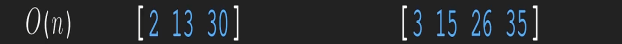

And lastly, we do it one more time for the final result.And that is another O(n)

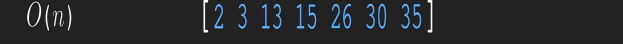

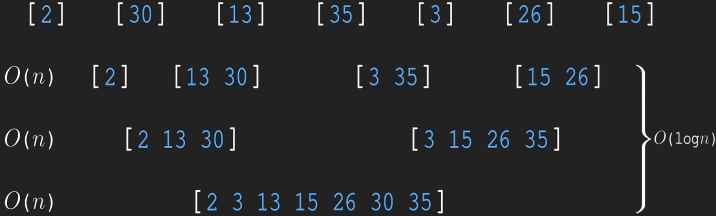

So each level of the recursive tree, we have to do operations that take in total O(n)time

The question now is how does the number of these levels grow compared to our input.Is it constant at 3 ?Does it grow linearly?
Back in recursion chapter, we learned how to calculate the complexity based on how we make the recursive calls. In merge sort, we divide our input by two with each function call, and that is an O(logn) action. 

So the depth of our tree will be the base two log of the size of our input. And if we put everything together, we can conclude that we do an O(n) operation a total of log ntimes, and that gives us a final complexity of **O of n times log n = O(nlogn)**.And the advantage of merge sort is that this is the performance for all cases.Best, worst and average. It doesn't care if the list is sorted, reversed or random, it will break it apart and put it back together the same way every time.

**Space complexity:**

When thinking about the memory usage, we need to consider all the extra arrays we're creating with each recursion call and after each merging.So with each level of the tree, we're adding more arrays to memory.But we also free up some of that memory after we merge them and the stack frames are cleared. After we sort the left half, we make the call to the right half and then recursively to all the subsequent halves.It's at this point we keep the most data in memory.

We have the first and second half using in total O(n) memory (refer below)

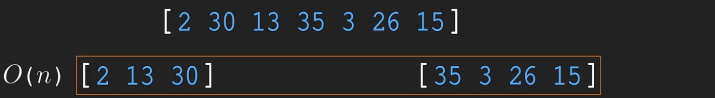

Then these two arrays using O(n) divided by two (refer highlighted section below).

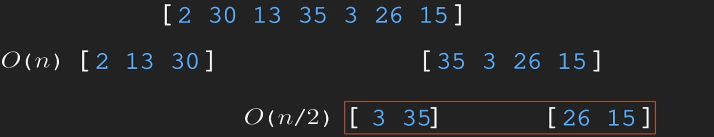

And then lastly these ones with O(n) divided by four (refer highlighted section below).

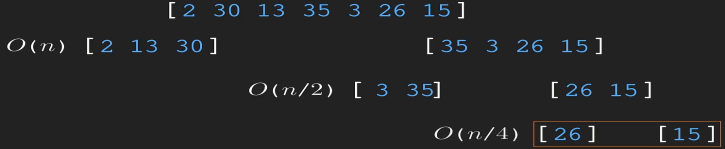

So as you can see in practice, it's actually a bit more than `O(n)`. We have `O(n)` plus `O(n/2)` plus `O(n/4)`.But that doesn't change the fact that the asymptotic complexity is still `O(n)`.

Let's see another diagram to better understand why. Let's say we have an array of size `16`.After calling Merge sort, we get the recursive tree we saw until now, with the input size divided by two on each level and with memory freed after each merging.And we end up with this case(below), which we said is where we use the most space.

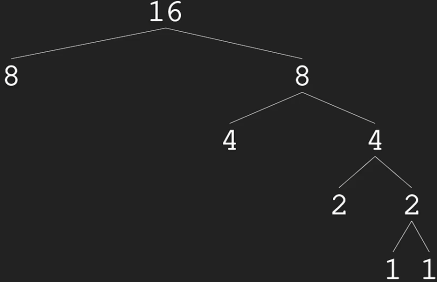

Let's actually count the size of our arrays we have now in memory. We have two(`1` & `1`) here at the bottom.And then we have these two (`2` & `2`) here, which are of size four with the two from before makes it six.We add that to the eight from here (`4` & `4`) and we get `14`.And finally adding that to the `16` from the first level we have `30`.**So we have extra 30 elements in memory from an original input size of 16**.

That's almost twice as much. So we can say that the memory usage grows up to `O(2n)`.And if you want to count the original input size, you would get `46`, which would be slightly less than `O(3n)`. Another thing to mention is that this being a recursive algorithm, we can also count the stack frames which contain additional information apart from the arrays we already counted. And that would add a logn to the equation. So in practice it's definitely more than a pure `O(n)`.But even if we consider it `O(3n)` plus `O(logn)` from the stack frames, we would still approximate that as `O(n)`.

In Summary...It's generally a very efficient algorithm in terms of runtime.O(logn), regardless of the state of the array, is as good as you can get with sorting algorithms. One drawback it has is its space complexity. O(n) might not sound like much, but if memory is a consideration or if our input is very large, then merge sort might not be the best solution. Another potentially surprising fact is that Merge sort is slower on small arrays than the simpler algorithms we learned, like insertion sort or bubble sort. Being a recursive algorithm, having all those function calls and stack frames actually makes mergesort slower on smaller arrays. And in fact, some optimization for merge sort include using insertion sort when the subarrays get smaller than some threshold, like 10 or 15.When we reach that limit, stop the recursive calls and do insertion instead, and that will slightly improve the performance.

##### Time Complexity of Merge Sort

- Best Case: O(nlogn)  
- Average Case: O(nlogn)
- Worst Case: O(nlogn)

##### Space : O(n)

#### Practical Use Case of Merge Sort
- **Where used**: Large datasets, external sorting (disk-based).
- **How used**: Stable sort, works well with linked lists and parallel processing.
- **Example**: Sorting huge files (like logs) that don’t fit into memory.

### Quick Sort

We'll cover another recursive sorting algorithm called quicksort. This one is also a very efficient and well-known algorithm, which was first published in 1961, and since then has remained one of the most used sorting methods in practice even to this day.

**Quicksort is also a divide and conquer algorithm**, just like merge sort in the sense that it will also divide the array into smaller and smaller pieces. But unlike merge sort, it won't sort them by merging elements into new arrays, but by swapping them in place.

Quicksort works on the idea of partitioning the array based on a pivot. It means that we have to choose one element from the array and use it as a reference when comparing elements, and we'll end up dividing the initial array into two parts with the smaller values in one part and the larger ones in the other. 

Let's use this array we have here as an example to better understand the procedure. We start off by choosing a pivot element from the list, and we could use pretty much any number. We could pick the first, the last, or just a random one. The core logic will be the same, whichever pivot we use, but the way we iterate and compare elements will be different depending on the position of the pivot.


In this version we will go with the last element(`42`) as the pivot. So the next step would be to divide the initial array into two sub arrays, one which has all the elements that are smaller than the pivot to the left, and all that are larger to the right. And we don't need them to be sorted just yet. We just want all the smaller ones to one side and the larger ones to the other. The way we do that is by scanning the array from start to finish using two pointers

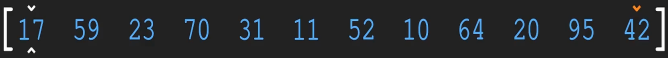

One pointer will keep track of the index where we will divide the array and the other will be in charge of going until the end. Comparing and swapping elements.

So in our example, both pointers will start at the first element (`17`). And we want to compare it to the pivot to `42`. Remember the pivot is our benchmark for comparisons. We want to split the array based on its value. `17` is less than `42`, so we want to keep it on the left side of the array, So we move both pointers one index up(`59`). And we now compare `59` to `42`.This one(`59`) is greater than `42`.So what we want to do now is to keep one pointer(`top arrow`) here (`59`), and we continue with the other pointer (`bottom arrow`) to the next element(`23`), in search of one that's smaller than the pivot(`42`).

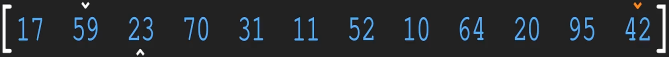

The next element is `23`, which is smaller than `42`.Because of that, we want to swap it with the last one. We verified that was greater than the pivot, which is `59`.And then we want to move the top pointer up by one(`59`). And start comparing the next element.(bottom pointer @ `70`). `70` is greater than `42`, So we don't do anything and we move(`bottom pointer`) on to the next one `31`. This time `31` is less than `42`.So we swap it again with the element from our top pointer(`59`) And then we move that up by one position(top pointer @`70`).

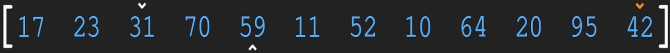

Let's take a break and review what we're doing here so that you have a better understanding of this algorithm and know what to look for going forward. So, we have a pivot element, which we decided was the last element of our array. This element we don't swap just yet. We only use it to compare other elements to it and nothing else for now. We then have the bottom pointer, which will run from the start of the array until right before the pivot. Its role is to compare the value at its index to the pivot. We don't compare it to the top pointer or any other element. We only compare it to the pivot. Always. But when we need to swap, we swap the value at the bottom pointer with the one at the top pointer. So we compare it to the pivot, but we swap it with the one at the top pointer. And I think this is the part that is most confusing when first learning this method. The fact that we compare it to one element but swap it with another.

so what about the top pointer? What role does it have?

If you look at the state of the array, you can notice that all the elements to its left are smaller than the pivot(`42`). Another way you can look at it is, is as if this top pointer acted as the border between the smaller elements and the larger ones. And we update that border with each element. We find that smaller than the pivot.

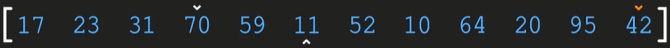

The bottom pointer is now at number `11`. We compare it to the pivot`42` and since it's smaller we need to move it past the border, which as you can see it's currently at the number `70`. So we swap the two values(`70` & `11`).

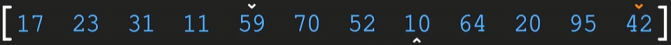

 Because we swapped and brought one more element to the left side. We need to move the top pointer one index up to `59`.And now we keep going with the bottom pointer. `52` is larger than `42` so we continue to the next element(bottom pointer @ `10`). `10` is smaller, so we swap with `59` and move the top pointer up (`70`) as shown below.

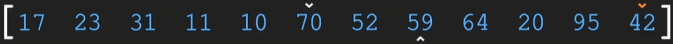

Next up(bottom pointer) is `64`, which is larger than `42`.So we move bottom pointer on to `20`.`20` being smaller, we swap with top pointer `70` and update the top pointer to `52`.

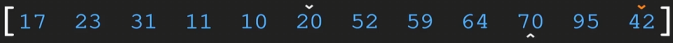

`95` (bottom pointer) is larger than pivot(`42`) so we don’t do anything.
And now we reached the end of the array. At this point, we don't need to update the bottom pointer one more time, because that would mean comparing the pivot (`42`) with itself, which is redundant. So what do we do now? Now we finally move the pivot. But where do we put it? We need to put it in a spot where all the elements smaller than it will be to its left, and all the ones larger to its right. And luckily, we know exactly where that spot is (`52`).

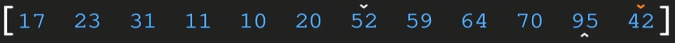

This is why we kept track of the top pointer all along. It serves as a limit where the smaller numbers end and the larger ones start. So we just swap the pivot with the element at the top pointer(`52`). And with that, we know for sure that `42` is in its correct spot in the array. And now the recursive nature of this algorithm comes into play. 

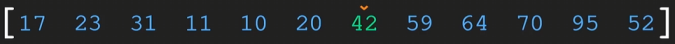

We can just apply the same logic to both of these sub arrays, which are separated by `42`.If we do the left one first, we would choose the last element as the pivot, which will be `20`, and then repeat the process.

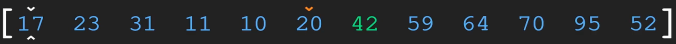

As shown above, We start with two pointers (`17`), one which will iterate until the end and compare to the pivot(bottom pointer), and one which serves as the boundary (top pointer).`17` when compared to `20` is smaller so we move (both pointers) on to `23`, `23` is greater than `20` , so the top pointer will stop there (`23`) but the bottom one will keep searching for one that is smaller(`11,10`) and we reach 11.We swap it with `23`(with top pointer) and then move the boundary up by one index(`11` to `31`). Bottom pointer is at `10`, which is also smaller than `20`, so we swap again with `31`.

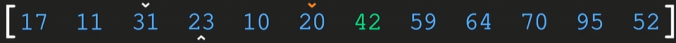

And since we reached the end of this sub array, we swapped the pivot `20` with the number at the top pointer which is `23`,and like before we repeat the recursive procedure starting from top pointer, which is `20`. We start working with smaller and smaller arrays,& when they end up one element long, we can stop the function call, since that's by definition already sorted.

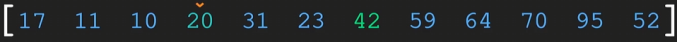

After the left part is sorted, the recursive process will move to the right one. Doing the same thing again until the entire array ends up sorted. And that is quicksort

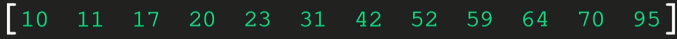

**Implementation :**

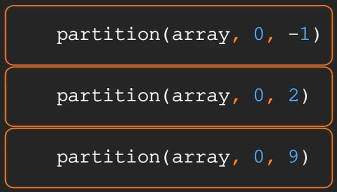

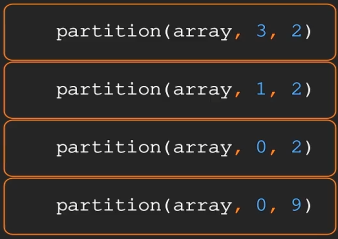

In [1]:
''' Main Function '''
def quick_sort(arr):
    if len(array)<2: # Checks if the array is empty or has only 1 element
        return arr
    return partition(arr, 0 , len(arr)-1) # we start as partition(array,0,9)

''' Helper Function '''
def partition (array, start, end): # we need start & end paramters so we can recursively call this fn unto certain parts of the input array
    if start >= end: # if start value is less or same as end then exit
        return
    pivot = end
    boundary = start#will be the upper index which will be over elements,greater than pivot/end & will be the one swapped with element smaller than pivot
    for i in range (start, end): #(0,9) ,"i" will be the lower index, going thru each elements one after another. it will keep going till index 8(95)
        if array[i] <= array[pivot]:# 17 vs 20
            array[boundary], array[i] = array[i] , array[boundary] #since i is 17 at start & so is boundary/start,it will swap by itself.Refer to * below
            boundary += 1 # upper index is updated to move to next element, after a swap is done and element lower than end/pivot replaces higher element
    array[boundary], array[end] = array[end] , array[boundary]#after i goes thru all elements & no more swaps left,end(20) will be swapped with bound(70)
    partition(array, start, boundary - 1)#since the boundary(upper index) is still at 3(20),new end would be boundary-1 = 2(10), partition(array, 0, 2)
# since the end element has to be 1 behind, we use boundary - 1 to address that. This recursion fn call is for left part of the array   
    partition(array, boundary + 1, end) # second call is for right part of the array & thats why start is boundary + 1
    return array

*i will be 0 in the first run, and when we compare 17 with the pivot, this line will evaluate to true. So, we'll perform a swap between 17 and itself. This is obviously not needed, and we could fix that easily by adding another check between if & swap line code, comparing i to the boundary. And if they're equal, we wouldn't swap. But this redundant move we don't do too often. So, it's the same discussion we had in the selection sort, where we need to think if it's worth having a condition check for each and every swap just because we do one unnecessary swap once in a while. This is a type of micro-optimization that's rather situational.


In [3]:
array =[17,59,23,70,31,11,52,10,64,20,95,42]
qs = quick_sort(array)

In [5]:
print(qs)

[10, 11, 17, 20, 23, 31, 42, 52, 59, 64, 70, 95]


In [ ]:
   0   1   2   3   4   5   6   7   8   9  
[ 17  59  23  70  42  11  10  31  95  20 ]

**Adding print command to query for control flow tracking**

In [11]:
def quick_sort(arr):
    if len(array)<2: # Checks if the array is empty or has only 1 element
        return arr
    return partition(arr, 0 , len(arr)-1) # we start as partition(array,0,9)

def partition(array, start, end):
    if start >= end:
        return
    pivot = end
    boundary = start
    print(f"\npartition(start={start}, end={end}, pivot=[{pivot}]{array[pivot]})")
    for i in range(start, end):
        print(f"  i={i}: [{i}]{array[i]} ≤ [{pivot}]{array[pivot]} ?", end=" ")
        if array[i] <= array[pivot]:
            print(f"swap([{boundary}]{array[boundary]},[{i}]{array[i]})")
            array[boundary], array[i] = array[i], array[boundary]
            boundary += 1
        else:
            print("no swap")
        print("   array:", " ".join(f"[{idx}]{val}" for idx,val in enumerate(array)),
              f" boundary=[{boundary}]{array[boundary] if boundary<=end else 'X'}")
    print(f"  final swap pivot([{pivot}]{array[pivot]},[{boundary}]{array[boundary]})")
    array[boundary], array[end] = array[end], array[boundary]
    print("   array:", " ".join(f"[{idx}]{val}" for idx,val in enumerate(array)))
    partition(array, start, boundary - 1)
    partition(array, boundary + 1, end)
    return array

In [17]:
array =[17,59,23,70,31,11,52,10,64,20,95,42]
qs = quick_sort(array)


partition(start=0, end=11, pivot=[11]42)
  i=0: [0]17 ≤ [11]42 ? swap([0]17,[0]17)
   array: [0]17 [1]59 [2]23 [3]70 [4]31 [5]11 [6]52 [7]10 [8]64 [9]20 [10]95 [11]42  boundary=[1]59
  i=1: [1]59 ≤ [11]42 ? no swap
   array: [0]17 [1]59 [2]23 [3]70 [4]31 [5]11 [6]52 [7]10 [8]64 [9]20 [10]95 [11]42  boundary=[1]59
  i=2: [2]23 ≤ [11]42 ? swap([1]59,[2]23)
   array: [0]17 [1]23 [2]59 [3]70 [4]31 [5]11 [6]52 [7]10 [8]64 [9]20 [10]95 [11]42  boundary=[2]59
  i=3: [3]70 ≤ [11]42 ? no swap
   array: [0]17 [1]23 [2]59 [3]70 [4]31 [5]11 [6]52 [7]10 [8]64 [9]20 [10]95 [11]42  boundary=[2]59
  i=4: [4]31 ≤ [11]42 ? swap([2]59,[4]31)
   array: [0]17 [1]23 [2]31 [3]70 [4]59 [5]11 [6]52 [7]10 [8]64 [9]20 [10]95 [11]42  boundary=[3]70
  i=5: [5]11 ≤ [11]42 ? swap([3]70,[5]11)
   array: [0]17 [1]23 [2]31 [3]11 [4]59 [5]70 [6]52 [7]10 [8]64 [9]20 [10]95 [11]42  boundary=[4]59
  i=6: [6]52 ≤ [11]42 ? no swap
   array: [0]17 [1]23 [2]31 [3]11 [4]59 [5]70 [6]52 [7]10 [8]64 [9]20 [10]95 [11]42  boundary=

#### Time And Space Complexity

As we just saw, this is also a recursion algorithm just like merge sort. Lets look back at how we determined the time performance of merge sort. We basically determined the complexity of the operations we do in one function call, and then multiplied that by the number of recursive calls.

If we have a look at our code here, we can see that we do a loop over the entire array from start to finish, even if with each invocation we loop over a smaller array because we partitioned it, we would still need to do it on the second part of the array at some point. So that would again mean we do one full iteration, which is O(n) complexity with each level of recursive calls.

Speaking of levels of recursion, when we discussed merge Sort, we saw that we had a number of logn levels. That was because we were dividing the input array in half with each call. Does that happen here as well? Not always. It's true that we petition our array in two parts, but it's not always in half. In the best case, yes, our pivot would split our array in half every time, and we would have a performance of O(n) multiplied by O(logn), and that would also be the average performance. But the worst case performance for quicksort is O(n)squared.

Space complexity: We had O(n) performance because we were creating a new array every time we merged, and we actually ended up using a bit more extra memory compared to the size of the input array.But the overall performance was O(n).

So how much would quicksort use? 
Well, unlike merge sort, quicksort doesn't create additional arrays. To occupy more memory, we swap items in place. So in this regard, the space we use to store our array does not change. But we do something more than just keeping an array in memory. We have recursion calls, and those take some space to space that's equal to the number of levels in the stack frames.

And like we discussed, if we partition the array roughly in half we would have logn levels. And that would be the final memory utilization of quicksort. Now let's get back to why the worst performance is O(n).

Let's take this sample array, which is already sorted. When our algorithm runs, it will choose the last element as the pivot and then starts iterating from the beginning. Because our pivot is the largest number in the whole list, it will never have to swap any values, and we don't end up dividing the array at all.Technically, we divide it in two, with the left part starting from zero and ending at the pivot, and the right part will be an empty array that will return immediately. But this division defeats the purpose of quicksort, and all the following runs will yield the same results. We never swap, and we iterate over all the remaining elements with each recursive call.And because we never split the array, we'll have n levels of recursion and n levels of recursion multiplied by n iterations over the elements of an array will give us O(n)squared complexity.

So could we do anything about that? Well, it all depends on how evenly we divide the array. And that in turn depends on the pivot. Ideally we want to pick a pivot which will divide the array in half with each iteration.That pivot will be the middle value out of all elements. But picking the middle value from an array you're trying to sort is not an easy task. But there are solutions that might give us some good approximations. One of these solutions is to randomly pick three numbers from the array and then select the median outof them, which is the middle value.In this case, the median would be 31.This might or might not give us an even split, but it's the best option out of the three.And sure, there is a possibility that all the three selected numbers would be the three largest from the list, but that would be highly unlikely. This, of course, would also mean changing the implementation a bit, since our pivot is not at theend of the array anymore. So as you can see, there is more than one way to write this algorithm. And in fact, quicksort refers more to a family of sorting methods that all work on the partitioning routine rather than one single implementation. You can read some more if you're curious.There are other ways of writing this algorithm, where we start at both ends and iterate towards eachother.There are some iterative versions.We can also optimize it to do insertion sort when the list gets too small. There are variants that use more than one pivot. And the reason there has been so much time invested in developing all those variants of quicksort isbecause, as the name suggests, it is indeed 

##### Time Complexity of Quick Sort

- Best Case: O(nlogn)  
- Average Case: O(nlogn)
- Worst Case: O(n²)

##### Space : O(logn)

#### Practical Use Case of Quick Sort
- **Where used**: General-purpose sorting in most libraries.
- **How used**: Fast average-case performance, widely adopted in practice.
- **Example**: Default sorting algorithm in languages like C, Java, and Python (Timsort is hybrid but inspired by quicksort).

### Radix Sort

Radix sort is different from all the others we learned until now in one fundamental way, because you see, all the algorithms we saw until now were sorting data by doing comparisons.  They were either comparing elements right next to each other, like insertion or selection sort, or elements further apart, like shell or quicksort and even heapsort, which was comparing elements only to build a heap and then use that to swap them to their correct place. But the point is that all of these algorithms belong to this group called **comparison sorting algorithms.**  

They all did at some point in their logic, some comparisons, they were taking two elements and were determining that one was either smaller or larger. And then based on that, they were placed in a sorted position. Radix sort is different in that regard. It sorts data without doing any comparisons. Instead, it does it by reading the digits of the numbers and distributing them into containers, to then be reallocated in the list in a sorted manner.

**How does it work ?**

To better understand how it works, let's take the below list as an example

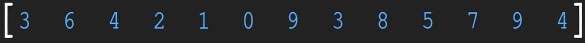

We need `ten buckets`, each representing every single digit base ten number. These are nothing but `containers` like lists or queues that can store data. And the way we do this sort is by iterating over the numbers and placing each one of them in its corresponding bucket. Example: `3` goes in the `3` bucket, `6` in the `6` bucket, and so on until all of them end up in the buckets. Even if we have duplicates, we still add them to their matching bucket.

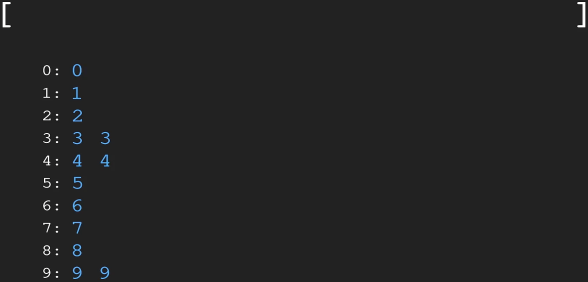

After we went over all the numbers in the input array, **we then just read the contents of all the buckets from `0 to 9` and add all the numbers to a new array. It's important to emphasize that we have to read the buckets in that precise order from `0 to 9`. Otherwise, the end result will not be a sorted array. And we can see that our array is now sorted**

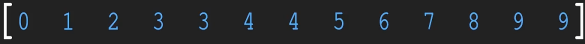

In this example, though, we use numbers from 0 to 9. But what if we want to sort numbers larger than that? Do we have to make more buckets? If we had to sort a list of numbers that go until 1 million, would we need that many buckets?

We would still only need these ten `(0-9)`. We already have. Let's see how we can do that with this new list we have here. These range from single digit numbers to four digits.

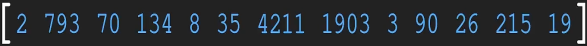

The way we would sort them would be to first put them into buckets according to their rightmost digit as highlighted in orange below. 

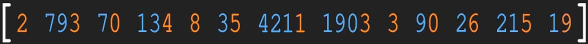

The first one is easy being a single digit number, it will go in the `2` bucket. But then we have `793`.We want to place this number in the bucket represented by the last digit which is `3`.So we place it in the three bucket. 70's last digit is `0`, so it goes into the `zero` bucket. And we repeat the same logic for all the following numbers.


One important thing to mention is that when we have more numbers with the same last digit, like `1903`, it will go in the bucket after the one that's already in the bucket. So we don't place it in front of `793`.**We want to preserve the order in which they were added**. And the same goes for the number `3`, even if it's the smallest among all the ones that are in the `3` bucket, we don't add it in front of the others. **It's not our goal to have sorted buckets that will happen naturally with each iteration**. We want to add new numbers at the end of existing ones, and it's not an issue if we have buckets that are empty, like the `7` bucket. In this case, it just means we didn't have any number that had `7` as their rightmost digit.

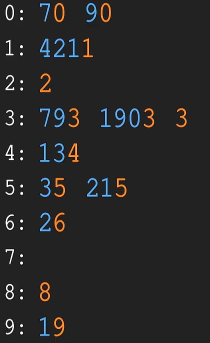

And now after we have all the numbers in the buckets, we need to put them back in the array starting from the `0` bucket. Then from the `1` bucket, and so on.

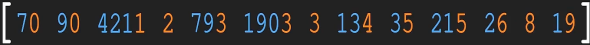

Notice another important thing. When we bring the numbers back from the buckets, we do it from left to right. So since 793 was the first to be added to its bucket, when we add it to the list, the order will be maintained. Essentially, **the buckets will act like queues. The first one in will be the first one out.**

And now with the new list, we would do the same thing, only this time we distribute them based on the **second digit** from the right(now highlighted below in orange). You might think that the single digit numbers like 2 or 3 don't have a second digit, but in reality they do. We just don't write it. **All these single digit numbers have zero as the next digit to the left e.g. 002, 003, 008 .So when we put them in buckets they will go in the zero bucket.**

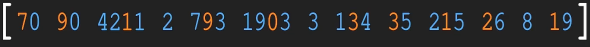

Okay, so let's get back to this list. The first number (`70`) will go in the `7` bucket. It doesn't matter in which bucket it was previously. In this iteration, we're only distributing them based on the second digit. `2` will go in the `zero` bucket like we just discussed, single digits are actually prefixed with `zeros. e.g. 002`. And then all the other numbers will go in their corresponding buckets, still following the same rule of going after any existing numbers in their bucket. 

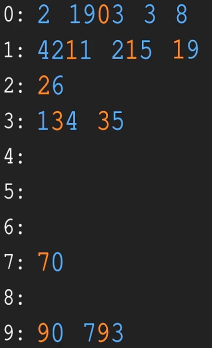

After that, we again empty the buckets starting from `0 to 9` and preserving the order of numbers in them, creating our new array as shown below. And then we just continue with the `third` digit of each number as highlighted below in orange

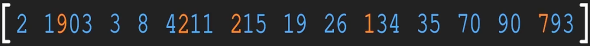

**How do we determine what is the digit at each position?**

For you and me it's easy. We just look at the number and put them in the correct bucket. But how will our computers do that? How can we make our computers understand that the third digit of `4211` is a `2`, and that it should go in the two bucket? The answer is math. There is a mathematical formula that gives us a digit at every position of any integer. 

And let's take this number `8359`as an example to illustrate it.

So, the formula goes like this. We need to take our target number (`8359`) and divide it by `10`, raised to the power of the position of our digit (`9` with index as `0`).The position is counted from the rightmost digit starting at `0`, and then incremented by one as we keep going to the left. So for this number, the digit at position `zero` is `9`, and if we want our formula to give us `9`, we would need to raise `10` to the power of `0`  as highlighted below

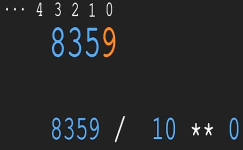

If we wanted to find the digit at position `1`, we would raise ten to the power of `1`.

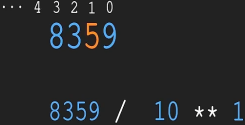

For `3`, that would be position `2`. Okay, so what do we have until now? `10` to the power of `2` is `100`. `8,359` divided by `100` is `83.59`. But we don't need the decimals for this formula. So, we want to get rid of them. What we need now is to perform a flawed division or an integer division. We already learned that in Python this is done by having two forward slashes `(//)` instead of one `(/)`. And this would give us only the integer part of our result, disregarding everything that comes after the decimal point. It's important to note that this is not a rounding operation. We don't round the number up or down; we just remove any decimals.

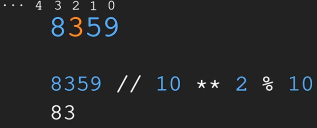

After that, we want to take the remainder of the division between our result and `10`. That is done with the modulo operation `(%)`, which in Python is written as the percentage sign `(%)`. And this is how it works. Our result until now is `83`. We divide that by `10` and we get `8.3`. The remainder of this division is what's after the decimal point, which in our case is `3 (3 from 8.3)`. So, all these calculations gave us `3`, which is exactly the digit at position `2(index value)`.

If we want to get the digit at position `3`, for example, all we need to change is the power to which we raise `10`, and our results should be `8`.

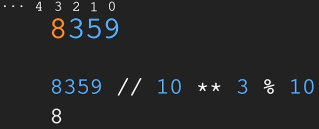

And this formula will work for any number as long as it's positive. To make it work on negative numbers, you would have to take the absolute value of the number and then plug it in the formula.

Now moving on to distributing list based on the `third digit` as highlighted in below list (in Orange)

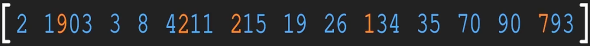

We're only considering the digit at position `2` in our numbers, which is the third digit from the `right` (index). Again, `single digits` go in the `zero` bucket, the ones with `2` as the `third digit` go in the `2` bucket. And when we reach the numbers with only `two digits`, they will also go in the `zero` bucket because their `third digit` is a `zero` (e.g. `002 ,003 ,008 ,019 ,026 ,035 , 070 & 090`).

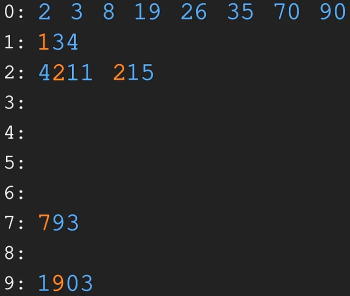

After all the numbers are in the buckets. We again build the new array starting from the zero bucket and preserving the order of numbers.

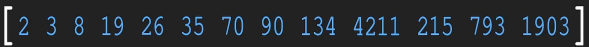

And next we take the digit at position three(4th Digit) and we repeat the process.

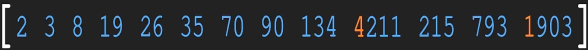

This is how list values are sorted/segregated in their respective buckets during each phase

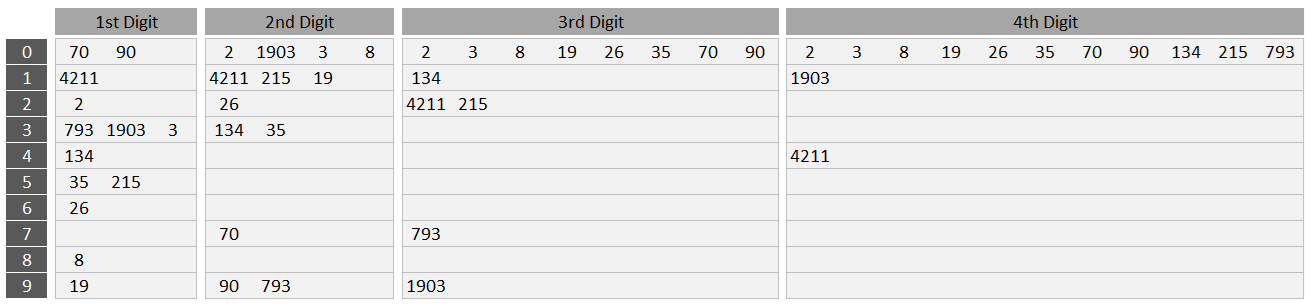

Final Sorted and compiled list after each Phase

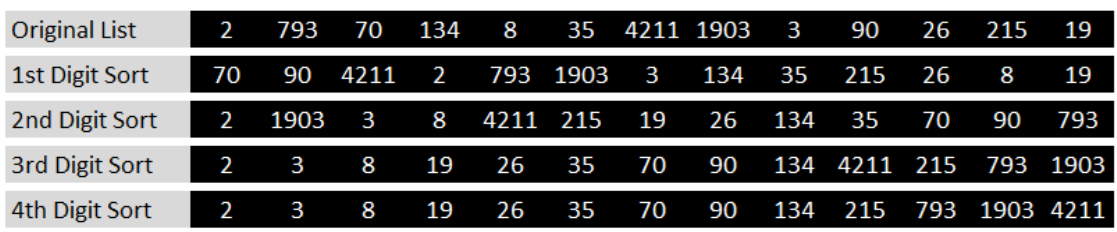

But now we need to ask ourselves another question. When do we stop with the iterations? When do we know we reach the point where our list is sorted and we don't need to do anything else?

And we actually have more than one answer for that. One way to know when we're done is by checking the length of the zero bucket. If we keep increasing the position of the digit we check, we will eventually end up with a position that is large enough and no number will have any digit at that position, so they will all end up in the zero bucket. And if the length of our input array is the same as the length of the zero bucket, we can stop the program and consider our array sorted.

But there is another way to know when to stop. If we knew how many digits the largest numbers in our list have, we would know from the start how many times to iterate. But now the question is, how can we check the number of digits that a number has? And the answer for that is again, math. We have another formula that will give us the number of digits of any integer.

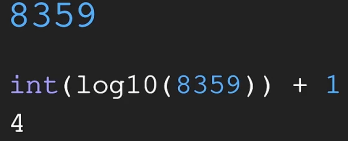

And let's use the same number `(8359)` as before to understand how it works. What we need to do here is to first take the `base ten log of the number`. And for our example, the result of that would be approximately `3.922`. But we again only need the integer part. We want to disregard everything that comes after the decimal point. So our result until now is `3`. What we then need to do is to just add one and we get `4`. And that is exactly how many digits `8359` has `(4)`.

This formula also works with positive integers only. So, **if you want to find out how many digits a negative number has, you'll need to use its `absolute value`. And for this formula, we actually have one more exception, which is the number `0`. Taking the `log of zero` is an operation that's not accepted in mathematics. So for `zero` we would have to not use the formula and just give the default value of `1`.**

Example below highlighting how log of zero is handled vis a vis rest.

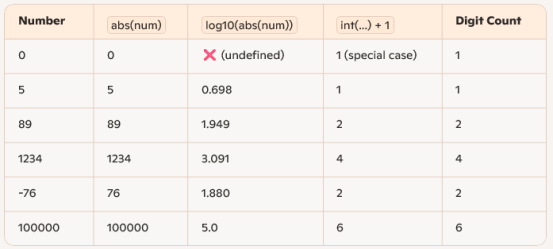

So in our implementation of radix sort, we will keep up with the theme of math and formulas and use this second method to know when to stop. We'll do one initial iteration over the entire array and apply the formula for every number, and just take the maximum value from the result. In our list, the maximum number of digits will be `four`, because our largest number is `4211` and `1903` both have `four digits`. We don't have any number with `five`. So, this iteration you see right now is the `fourth` and `last one`. After we're done, our list should be sorted. 

So, let's see. All the elements of the first half will be placed in the zero bucket (as shown below), and when we reach `4211`, we place it in the `4` bucket. The next two will go in the `zero bucket`, and finally `1903` in the `1 bucket`.

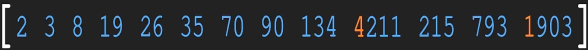

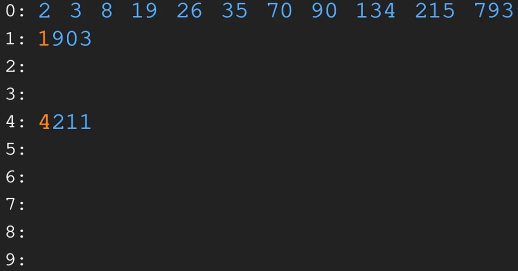

And now we take one last time the elements from the buckets in the order they're in, and put them in a new array, which is indeed sorted

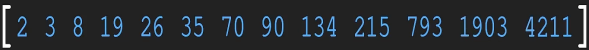

So, to sum up the steps of this algorithm, 
 1. We first need to know what's the maximum number of digits our numbers reach. And we do that by applying the last formula we talked about on every number in our list. And then choose the maximum value. This is for us to know how many times to repeat the process of adding two buckets and creating a new array out of them. 
 2. We then need a loop that starts at zero and goes for a total number of times equal to this value we computed in the first step. It can be a for loop or a while loop. It doesn't matter. 
 3. We then need to define 10 buckets to store our numbers in. They can be any container object. The simplest way would be with regular lists. After that, 
 4. We loop over every number in the array and we calculate the digit at the current position we are in the main loop, and then based on the result, we add it to its corresponding bucket. 
And the last thing would be to iterate over the buckets and make a new list with the numbers in the order they appeared in the buckets. And that's radix sort.

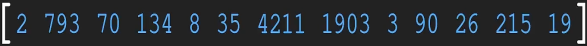

In [88]:
import math

''' Main Function '''
def radix_sort(array): # Function to accept array as a parameter
    max_digits = get_max_number_of_digits(array)# Finds the maximum number of digits in any number in the array.      
    ''' This tells us how many passes we need (one for each digit position) '''
    for i in range(max_digits + 1): # start defaults to 0, and stop is omitted! e.g. range(4) produces 0, 1, 2, 3, hence +1 used, to cover 4
        buckets = [[] for _ in range(10)]# Creates 10 empty buckets(lists)for digits 0-9.Each bucket will temp hold numbers based on the current digit.
# e.g of buckets => [[], [], [], [], [], [], [], [], [], []]
        for num in array:
            digit = get_digit_at_position(num, position = i) # Extracts the digit at the current position i from the number num. 
# For example, if num = 345 and i = 1, it gets the tens digit (4).
            buckets[digit].append(num)#Places the number into the corresponding bucket based on the digit extracted,using above e.g 345 is placed in [4]
        array = flatten(buckets)# Flattens the list of buckets back into a single list,preserving the order.
                                # This becomes the new array for the next digit pass.
    return array # After all digit positions have been processed, the array is sorted and returned.
    
''' Helper Function - Calculates the number of digits in each number using logarithms '''
def get_max_number_of_digits(array):
    return max(int(math.log10(abs(num))) + 1 if num !=0 else 1 for num in array) #  
# in python we have built in fn in math module, to calculate the logbased 10 of a number. We are also using a comprehension construct to loop thru all
# elements in the array to find the Maximum. Remember that log of zero(math.log10(0)) is an operation thats not accepted in mathematics.In Python,
# it raises a ValueError: math domain error. Hence for zero(math.log10(0)) we manually return 1 digit, using the else function above.

# The abs() function in Python is a built-in function that returns the absolute value of a number. The absolute value of a number is its distance from 
# zero on the number line, regardless of its sign. This means that for a positive number, abs() returns the number itself, and for a negative number, 
# it returns the positive equivalent of that number.

''' Helper Function - Extracts the digit at a specific position'''
def get_digit_at_position(number, position):
    return(abs(number) // 10 ** position) % 10

''' Helper Function - Flattens a list of lists into a single list. e.g - [[1,2], [3], [4,5]] → [1,2,3,4,5] '''
def flatten(array):
    return[num for inner in array for num in inner]


# result = [ ] - Simplified code  => array = [[1, 2], [3, 4], [5]]
# for inner in array :  - For each inner list in array => FIRST LOOP => Iteration 1:inner = [1, 2], Iteration 2:inner = [3, 4], Iteration 3:inner = [5]
#	for num in inner: - For each num in that inner list => SECOMD LOOP => When inner = [1, 2] → num = 1, then num = 2 
                       # When inner = [3, 4] → num = 3, then num = 4 |  When inner = [5] → num = 5
#	result.append(num) - Add num to the final flattened list


**Modified Code to track control flow**

In [98]:
import math

def radix_sort(array):
    max_digits = get_max_number_of_digits(array)
    print(f"Max digits in array: {max_digits}\n")

    for i in range(max_digits + 1):
        print(f"--- Pass {i} (digit position {i}) ---")
        buckets = [[] for _ in range(10)]
        
        for num in array:
            digit = get_digit_at_position(num, position=i)
            print(f"Number: {num}, Digit at position {i}: {digit}")
            buckets[digit].append(num)
        
        print(f"Buckets after pass {i}: {buckets}")
        array = flatten(buckets)
        print(f"Array after flattening: {array}\n")
    
    return array

def get_max_number_of_digits(array):
    return max(int(math.log10(abs(num))) + 1 if num != 0 else 1 for num in array)

def get_digit_at_position(number, position):
    return (abs(number) // 10 ** position) % 10

def flatten(array):
    return [num for inner in array for num in inner]

In [100]:
array =[2,3,8,19,26,35,70,90,134,215,793,1903,4211]
array

[2, 3, 8, 19, 26, 35, 70, 90, 134, 215, 793, 1903, 4211]

In [102]:
rs=radix_sort(array)

Max digits in array: 4

--- Pass 0 (digit position 0) ---
Number: 2, Digit at position 0: 2
Number: 3, Digit at position 0: 3
Number: 8, Digit at position 0: 8
Number: 19, Digit at position 0: 9
Number: 26, Digit at position 0: 6
Number: 35, Digit at position 0: 5
Number: 70, Digit at position 0: 0
Number: 90, Digit at position 0: 0
Number: 134, Digit at position 0: 4
Number: 215, Digit at position 0: 5
Number: 793, Digit at position 0: 3
Number: 1903, Digit at position 0: 3
Number: 4211, Digit at position 0: 1
Buckets after pass 0: [[70, 90], [4211], [2], [3, 793, 1903], [134], [35, 215], [26], [], [8], [19]]
Array after flattening: [70, 90, 4211, 2, 3, 793, 1903, 134, 35, 215, 26, 8, 19]

--- Pass 1 (digit position 1) ---
Number: 70, Digit at position 1: 7
Number: 90, Digit at position 1: 9
Number: 4211, Digit at position 1: 1
Number: 2, Digit at position 1: 0
Number: 3, Digit at position 1: 0
Number: 793, Digit at position 1: 9
Number: 1903, Digit at position 1: 0
Number: 134, Digit

And that's how Radix Sort works, at least this version of it, because this is actually only one of many variations of this type of sort. This particular solution is rather simple, and it only works with positive integers. It won't work with negative numbers. It won't work with floating point numbers, and neither will it work with other data types

**Where is the "storage" happening for get_max_number_of_digits ?**
- The expression inside max(...) is a generator expression:
(int(math.log10(abs(num))) + 1 if num != 0 else 1 for num in array)
- This doesn’t explicitly store all values in a container like a list. Instead, it generates values one by one as max() requests them.
- The max() function then consumes this generator:
- It starts with the first generated value and keeps track of it as the current maximum.
- For each subsequent value, it compares it with the current maximum and updates if the new value is larger.
- At the end, it returns the largest value found.

So, there’s no separate container holding all digit counts. The values are produced on the fly, and max() internally keeps only the current maximum in memory.

**Analogy**

Think of it like a running competition:
- Each runner (number in the array) shows up one at a time.
- The judge (max) only remembers the fastest runner so far.
- At the end, the judge announces the winner without ever keeping a full list of all times.


**Comprehension construct simplified**

In [24]:
array =[2,3,8,19,26,35,70,90,134,215,793,1903,4211]

In [26]:
# Actual code 1 :
max(int(math.log10(abs(num))) + 1 if num !=0 else 1 for num in array) 

4

In [28]:
# Simplified code:
for num in array:
    if num != 0:
        digits = int(math.log10(abs(num))) + 1
    else:
        digits = 1

In [30]:
# Actual code 2 :
buckets = [ [ ] for _ in range(10) ]

# Simplified code :
buckets=[ ]
for _ in range(10):
   buckets.append( [ ] )

In [ ]:
# Actual code 3 :
[num for inner in array for num in inner]
# [] This flattens a nested list (list of lists) into a single list.

# Simplified code :
result = [ ]
for inner in array:
    for num in inner:
        result.append(num)

**Step-by-step explanation for code 3**

Suppose: array = [[1, 2], [3, 4]]

The comprehension has two for loops inside it:
- `for inner in array` → this means: take each sublist ([1,2], then [3,4]) one by one.
- `for num in inner` → for each element inside that sublist, take the number.
- `num` → collect that number into the result list.

    
So the control flow is:
- First inner = [1, 2]
   - Then num = 1 → add 1
   - Then num = 2 → add 2
- Next inner = [3, 4]
   - Then num = 3 → add 3
   - Then num = 4 → add 4

Final result: [1, 2, 3, 4]

**Analogy**

Think of it like nested trays of chocolates:
- The outer loop picks up each tray (inner).
- The inner loop picks up each chocolate (num) inside that tray.
- You put each chocolate into one big box (result).


So `[num for inner in array for num in inner]` is just a compact way of saying:
“Go through every tray, then every chocolate in that tray, and collect them all.”

**How Python handles list references and mutation.**

In [11]:
pp = [[] for _ in range(10)]
pp

[[], [], [], [], [], [], [], [], [], []]

In [5]:
# we can confirm this by checking
type(pp[0])

list

In [7]:
len(pp[0])

0

In [9]:
pp[7].append(170)
pp

[[], [], [], [], [], [], [], [170], [], []]

So the structure is always there, Python just shows it as a compact list of lists. You're not seeing "buckets[0] == []" printed individually unless you ask for it

#### Time And Space Complexity

Let's now discuss the complexity of radix sort. This solution will run in O of n times k time (O(nk)), with `n` being the length of the array and `k` being the number of digits of the largest number.

The first `for loop` will run k times, and then inside it we have to O(n) operations one at `second for loop`, where we loop over the arrays to check their digit, and one time at `array = flatten(buckets)` where we get the numbers out of the buckets. And depending on how large our numbers are, this `k` might get quite big. And in such a scenario, the time complexity might get closer to O(nlogn), just like the comparisons sorts.

The discussion gets even more nuanced if we start talking about different implementations of these algorithms and how different computers store numbers in memory, which might actually make some comparison sorts more effective than certain versions of radix sort. And it's the same story with the space complexity.

The version we have here uses an additional O(n) space. When we add the numbers in the buckets, and again O(n) for the result array at `array = flatten(buckets)`. Our version is called the least significant digit version because we're starting to sort using the right most digit, the so-called least significant one. But there are some other versions of radix sort that use a different sorting subroutine, and the generally accepted complexity is `O(n+k)`.

Complexity analysis for radix sort is dependent on many factors like the data types we are sorting, specific implementations of the algorithm and the way machines store data.

##### Time Complexity of Radix Sort

- Best Case: O(nk)  
- Average Case: O(nk)
- Worst Case: O(nk)

##### Space : O(n+k)

#### Practical Use Case of Radix Sort
- **Where used**: Sorting integers, strings, or fixed-length keys.
- **How used**: Non-comparison sort, efficient for large datasets with bounded keys.
- **Example**: Sorting phone numbers, postcodes, or large datasets in databases.

---

### Key Takeaway
- **Simple sorts (Insertion, Selection, Bubble)** → Educational or niche hardware use.
- **Efficient sorts (Shell, Heap, Merge, Quick)** → Real-world applications in libraries, systems, and large-scale data.
- **Specialized sorts (Radix)** → Best for integers/strings with fixed ranges.